In [1]:
# Cell 1
import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

In [2]:
# Cell 2
with open("./hc-3-linear/processed/linear_rowwise.pkl", "rb") as f:
    data = pickle.load(f)

X = data["X"].astype(np.int64)
cov_df = data["cov_df"].copy()
unit_meta = data["unit_meta"].copy()

print(data["summary"])
print("X shape:", X.shape)
print("cov columns:", list(cov_df.columns))
N_BINS = 30

{'n_samples': 29239, 'n_neurons': 62, 'core_covariates': ['pos_smooth', 'direction'], 'optional_covariates': ['time_norm', 'x_norm', 'y_norm', 'x_raw', 'y_raw'], 'raw_2d_position_columns': ['x_raw', 'y_raw'], 'normalized_2d_position_columns': ['x_norm', 'y_norm']}
X shape: (29239, 62)
cov columns: ['time', 'time_norm', 'pos_smooth', 'direction', 'turning', 'x_raw', 'y_raw', 'x_norm', 'y_norm', 'direction01']


In [3]:
# Cell 3
keep = cov_df["direction"].isin([-1, 1]).to_numpy()
X = X[keep]
cov_df = cov_df.loc[keep].reset_index(drop=True)

pos = 2.0 * cov_df["pos_smooth"].to_numpy(dtype=np.float32) - 1.0
dir01 = (cov_df["direction"].to_numpy() > 0).astype(np.float32)

y = np.stack([pos, dir01], axis=1)

idx_pos = np.where(cov_df["direction"].to_numpy() == 1)[0]
idx_neg = np.where(cov_df["direction"].to_numpy() == -1)[0]

rng = np.random.default_rng(0)
rng.shuffle(idx_pos)
rng.shuffle(idx_neg)

ntr_pos = int(0.8 * len(idx_pos))
ntr_neg = int(0.8 * len(idx_neg))

train_idx = np.sort(np.concatenate([idx_pos[:ntr_pos], idx_neg[:ntr_neg]]))
test_idx  = np.sort(np.concatenate([idx_pos[ntr_pos:], idx_neg[ntr_neg:]]))

X_train = X[train_idx]
X_test  = X[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]
cov_train = cov_df.iloc[train_idx].reset_index(drop=True)
cov_test  = cov_df.iloc[test_idx].reset_index(drop=True)

print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)

train: (23391, 62) (23391, 2)
test : (5848, 62) (5848, 2)


In [4]:
# Cell 4
class CondMLP(nn.Module):
    def __init__(self, in_dim, out_dim, width=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, width),
            nn.SELU(),
            nn.Linear(width, width),
            nn.SELU(),
            nn.Linear(width, width),
            nn.SELU(),
            nn.Linear(width, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class PoissonMLP(nn.Module):
    def __init__(self, in_dim, out_dim, width=128, log_cap=12.0, eps=1e-8):
        super().__init__()
        self.base = CondMLP(in_dim, out_dim, width=width)
        self.log_cap = log_cap
        self.eps = eps

    def forward(self, x):
        z = torch.clamp(self.base(x), max=self.log_cap)
        return torch.exp(z) + self.eps


class CountFMNetAux(nn.Module):
    def __init__(self, d, c_dim_cfg, width=128, log_cap=5.0, eps=1e-8):
        super().__init__()
        self.d = d
        self.c_dim_cfg = c_dim_cfg
        self.log_cap = log_cap
        self.eps = eps

        self.state_net = nn.Sequential(
            nn.Linear(d + 1, width),
            nn.SELU(),
            nn.Linear(width, width),
            nn.SELU(),
        )
        self.cond_net = nn.Sequential(
            nn.Linear(c_dim_cfg, width),
            nn.SELU(),
            nn.Linear(width, width),
            nn.SELU(),
        )
        self.fuse_net = nn.Sequential(
            nn.Linear(2 * width, width),
            nn.SELU(),
            nn.Linear(width, width),
            nn.SELU(),
        )

        self.lam_head = nn.Linear(width, d)
        self.beta_head = nn.Linear(width, d)
        self.mean_head = nn.Linear(width, d)

    def _positive(self, z):
        z = torch.clamp(z, max=self.log_cap)
        return torch.exp(z) + self.eps

    def forward(self, inp):
        x_state = inp[:, :self.d + 1]
        cond = inp[:, self.d + 1:]

        hs = self.state_net(x_state)
        hc = self.cond_net(cond)
        h = self.fuse_net(torch.cat([hs, hc], dim=1))

        lam = self._positive(self.lam_head(h))
        beta = self._positive(self.beta_head(h))
        mu_hat = self._positive(self.mean_head(hc))

        return torch.cat([lam, beta, mu_hat], dim=1)


def sample_xt(x0, x1, t):
    with torch.no_grad():
        diff = x1 - x0
        sign = torch.sign(diff)
        n = diff.abs()
        b = torch.binomial(n.float(), t.expand_as(n))
        return x0 + sign * b.to(x0.dtype)


def sample_rt(xt, x1, t, eps_t):
    with torch.no_grad():
        idx_b = (x1 > xt).to(torch.float32)
        idx_d = (xt > x1).to(torch.float32)
        idx_0 = (xt <= 0).to(torch.float32)

        lam_star = idx_b * (x1 - xt) / (1.0 - t + eps_t)
        mu_star = idx_d * (xt - x1) / (1.0 - t + eps_t) * (1.0 - idx_0)

        rates_star = torch.cat([lam_star, mu_star], dim=1)
        return rates_star, idx_0


def countfm_loss(rates_theta, rates_star, eps=1e-8):
    u = rates_star
    v = rates_theta
    return (v - u * torch.log(v + eps)).sum(dim=1).mean()


def poisson_loss(rate, x, eps=1e-8):
    return (rate - x * torch.log(rate + eps)).sum(dim=1).mean()

In [5]:
# Cell 5
Xtr = torch.tensor(X_train, dtype=torch.float32, device=device)
Xte = torch.tensor(X_test, dtype=torch.float32, device=device)
ytr = torch.tensor(y_train, dtype=torch.float32, device=device)
yte = torch.tensor(y_test, dtype=torch.float32, device=device)

d = X_train.shape[1]
c_dim = y_train.shape[1]
fm_c_dim = c_dim + 1

mlp_mean = CondMLP(c_dim, d, width=128).to(device)
pois_mlp = PoissonMLP(c_dim, d, width=128).to(device)
fm_net = CountFMNetAux(d=d, c_dim_cfg=fm_c_dim, width=128, log_cap=5.0).to(device)

print("d =", d, "cov_dim =", c_dim, "fm_cov_dim =", fm_c_dim)

d = 62 cov_dim = 2 fm_cov_dim = 3


In [6]:
# Cell 6
def train_mean_mlp(net, X, y, epochs=200, batch_size=512, lr=1e-3):
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    n = X.shape[0]
    for ep in tqdm(range(epochs), desc="MLP mean"):
        perm = torch.randperm(n, device=X.device)
        for s in range(0, n, batch_size):
            idx = perm[s:s+batch_size]
            pred = F.softplus(net(y[idx]))
            loss = F.mse_loss(pred, X[idx])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
    return net


def train_poisson_mlp(net, X, y, epochs=200, batch_size=512, lr=1e-3):
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    n = X.shape[0]
    for ep in tqdm(range(epochs), desc="Poisson MLP"):
        perm = torch.randperm(n, device=X.device)
        for s in range(0, n, batch_size):
            idx = perm[s:s+batch_size]
            rate = net(y[idx])
            loss = poisson_loss(rate, X[idx])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
    return net


def train_countfm_cond(net, X, y, epochs=200, batch_size=512, lr=1e-3,
                       x0_rate=None, eps_t=1e-4, p_uncond=0.1, lambda_mean=0.1):
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    n, d = X.shape

    if x0_rate is None:
        x0_rate = float(X.mean().item())

    for ep in tqdm(range(epochs), desc="count-FM"):
        perm = torch.randperm(n, device=X.device)
        for s in range(0, n, batch_size):
            idx = perm[s:s+batch_size]
            x1 = X[idx]
            yb = y[idx]
            bsz = x1.shape[0]

            x0 = torch.poisson(torch.full_like(x1, x0_rate))

            keep_mask = (torch.rand(bsz, 1, device=X.device) > p_uncond).float()
            y_drop = yb * keep_mask
            y_cfg = torch.cat([y_drop, keep_mask], dim=1)

            t = torch.rand(bsz, 1, device=X.device) * (1.0 - 2.0 * eps_t) + eps_t
            xt = sample_xt(x0, x1, t)
            rates_star, idx_0 = sample_rt(xt, x1, t, eps_t)

            inp = torch.cat([xt, t, y_cfg], dim=1)
            out = net(inp)

            lam = out[:, :d]
            beta = out[:, d:2*d]
            mu = (xt * beta) * (1.0 - idx_0)
            rates_theta = torch.cat([lam, mu], dim=1)

            loss_rate = countfm_loss(rates_theta, rates_star)

            # auxiliary mean loss, always on the fully conditioned branch
            y_full = torch.cat([yb, torch.ones_like(keep_mask)], dim=1)
            inp_full = torch.cat([xt, t, y_full], dim=1)
            out_full = net(inp_full)
            mu_hat = out_full[:, 2*d:3*d]
            loss_mean = poisson_loss(mu_hat, x1)

            loss = loss_rate + lambda_mean * loss_mean

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
    return net

In [7]:
# New helper cell: checkpoint save/load
from pathlib import Path
import torch

CKPT_DIR = Path("hc3_ckpts")
CKPT_DIR.mkdir(exist_ok=True)

CKPT_PATH = CKPT_DIR / "hc3_models_v1.pt"

def save_hc3_checkpoint(path, mlp_mean, pois_mlp, fm_net, x0_rate, meta=None):
    payload = {
        "mlp_mean_state": mlp_mean.state_dict(),
        "pois_mlp_state": pois_mlp.state_dict(),
        "fm_net_state": fm_net.state_dict(),
        "x0_rate": float(x0_rate),
        "meta": {} if meta is None else meta,
    }
    torch.save(payload, path)
    print(f"saved checkpoint to {path}")

def load_hc3_checkpoint(path, mlp_mean, pois_mlp, fm_net, map_location=None):
    payload = torch.load(path, map_location=map_location)
    mlp_mean.load_state_dict(payload["mlp_mean_state"])
    pois_mlp.load_state_dict(payload["pois_mlp_state"])
    fm_net.load_state_dict(payload["fm_net_state"])
    x0_rate = float(payload["x0_rate"])
    meta = payload.get("meta", {})
    print(f"loaded checkpoint from {path}")
    return mlp_mean, pois_mlp, fm_net, x0_rate, meta

In [8]:
# Cell 7
x0_rate = float(X_train.mean())

# mlp_mean = train_mean_mlp(mlp_mean, Xtr, ytr, epochs=1000, batch_size=512, lr=1e-3)
# pois_mlp = train_poisson_mlp(pois_mlp, Xtr, ytr, epochs=1000, batch_size=512, lr=1e-3)
# fm_net = train_countfm_cond(
#     fm_net, Xtr, ytr,
#     epochs=1000,
#     batch_size=512,
#     lr=5e-4,
#     x0_rate=x0_rate,
#     p_uncond=0.1,
#     lambda_mean=0.1,
# )


# # Save checkpoint
# save_hc3_checkpoint(
#     CKPT_PATH,
#     mlp_mean=mlp_mean,
#     pois_mlp=pois_mlp,
#     fm_net=fm_net,
#     x0_rate=x0_rate,
#     meta={
#         "epochs": 1000,
#         "batch_size": 512,
#         "mlp_lr": 1e-3,
#         "fm_lr": 5e-4,
#         "p_uncond": 0.1,
#         "lambda_mean": 0.1,
#         "y_dim": int(y_train.shape[1]),
#         "d": int(X_train.shape[1]),
#     },
# )

# Load checkpoint
mlp_mean, pois_mlp, fm_net, x0_rate, ckpt_meta = load_hc3_checkpoint(
    CKPT_PATH,
    mlp_mean=mlp_mean,
    pois_mlp=pois_mlp,
    fm_net=fm_net,
    map_location=device,
)
print(ckpt_meta)

loaded checkpoint from hc3_ckpts/hc3_models_v1.pt
{'epochs': 1000, 'batch_size': 512, 'mlp_lr': 0.001, 'fm_lr': 0.0005, 'p_uncond': 0.1, 'lambda_mean': 0.1, 'y_dim': 2, 'd': 62}


In [9]:
# New cell: optionally continue refining 1-run count-FM checkpoint
# Place after Cell 7, before Cell 8
# Rerun Cell 8 and downstream cells after this cell

DO_REFINE_1RUN = False   # True: train more; False: skip training but load refined ckpt if present

REFINE_1RUN_EPOCHS = 500
REFINE_1RUN_BATCH_SIZE = 512
REFINE_1RUN_LR = 2e-4
REFINE_1RUN_P_UNCOND = 0.1
REFINE_1RUN_LAMBDA_MEAN = 0.1

REFINED_CKPT_PATH = CKPT_DIR / "hc3_models_v1_refined.pt"

# preserve original CKPT_PATH, even if this cell is run multiple times
if "_CKPT_PATH_BASE" not in globals():
    _CKPT_PATH_BASE = CKPT_PATH

if DO_REFINE_1RUN:
    start_ckpt_path = REFINED_CKPT_PATH if REFINED_CKPT_PATH.exists() else _CKPT_PATH_BASE
    print("loading 1-run checkpoint from:", start_ckpt_path)

    # reload latest available model, so repeated runs are cumulative
    mlp_mean = CondMLP(c_dim, d, width=128).to(device)
    pois_mlp = PoissonMLP(c_dim, d, width=128).to(device)
    fm_net = CountFMNetAux(d=d, c_dim_cfg=fm_c_dim, width=128, log_cap=5.0).to(device)

    mlp_mean, pois_mlp, fm_net, x0_rate, ckpt_meta = load_hc3_checkpoint(
        start_ckpt_path,
        mlp_mean=mlp_mean,
        pois_mlp=pois_mlp,
        fm_net=fm_net,
        map_location=device,
    )

    fm_net.train()

    fm_net = train_countfm_cond(
        fm_net,
        Xtr,
        ytr,
        epochs=REFINE_1RUN_EPOCHS,
        batch_size=REFINE_1RUN_BATCH_SIZE,
        lr=REFINE_1RUN_LR,
        x0_rate=x0_rate,
        p_uncond=REFINE_1RUN_P_UNCOND,
        lambda_mean=REFINE_1RUN_LAMBDA_MEAN,
    )

    fm_net.eval()

    ckpt_meta = {} if ckpt_meta is None else dict(ckpt_meta)
    ckpt_meta["refine_round"] = int(ckpt_meta.get("refine_round", 0)) + 1
    ckpt_meta["extra_countfm_epochs"] = int(ckpt_meta.get("extra_countfm_epochs", 0)) + REFINE_1RUN_EPOCHS
    ckpt_meta["last_refine_epochs"] = int(REFINE_1RUN_EPOCHS)
    ckpt_meta["last_refine_lr"] = float(REFINE_1RUN_LR)
    ckpt_meta["last_refine_batch_size"] = int(REFINE_1RUN_BATCH_SIZE)
    ckpt_meta["last_refine_p_uncond"] = float(REFINE_1RUN_P_UNCOND)
    ckpt_meta["last_refine_lambda_mean"] = float(REFINE_1RUN_LAMBDA_MEAN)

    save_hc3_checkpoint(
        REFINED_CKPT_PATH,
        mlp_mean=mlp_mean,
        pois_mlp=pois_mlp,
        fm_net=fm_net,
        x0_rate=x0_rate,
        meta=ckpt_meta,
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("saved refined 1-run checkpoint:", REFINED_CKPT_PATH)
    print("refine round:", ckpt_meta["refine_round"])
    print("extra count-FM epochs:", ckpt_meta["extra_countfm_epochs"])

else:
    print("DO_REFINE_1RUN = False, skipping refined training.")

# make Cell 8 use refined checkpoint automatically if available
CKPT_PATH = REFINED_CKPT_PATH if REFINED_CKPT_PATH.exists() else _CKPT_PATH_BASE

print("Cell 8 will load:", CKPT_PATH)

DO_REFINE_1RUN = False, skipping refined training.
Cell 8 will load: hc3_ckpts/hc3_models_v1_refined.pt


In [10]:
# Cell 8
@torch.no_grad()
def sample_countfm_cfg_batch(net, y, d, x0_rate, n_rep=16, n_step=1000, w=1.0, eps_t=1e-4):
    n = y.shape[0]
    c_dim = y.shape[1]

    y_rep = y.unsqueeze(0).expand(n_rep, n, c_dim).reshape(n_rep * n, c_dim)

    keep_c = torch.ones((n_rep * n, 1), device=y.device)
    keep_u = torch.zeros((n_rep * n, 1), device=y.device)

    y_c = torch.cat([y_rep, keep_c], dim=1)
    y_u = torch.cat([torch.zeros_like(y_rep), keep_u], dim=1)

    xt = torch.poisson(torch.full((n_rep * n, d), x0_rate, device=y.device)).float()
    t = torch.full((n_rep * n, 1), eps_t, device=y.device)
    delta = (1.0 - 2.0 * eps_t) / n_step

    for _ in range(n_step):
        inp_c = torch.cat([xt, t, y_c], dim=1)
        inp_u = torch.cat([xt, t, y_u], dim=1)

        out_c = net(inp_c)
        out_u = net(inp_u)

        lam_c, beta_c = out_c[:, :d], out_c[:, d:2*d]
        lam_u, beta_u = out_u[:, :d], out_u[:, d:2*d]

        lam = torch.clamp(lam_u + w * (lam_c - lam_u), min=1e-8)
        beta = torch.clamp(beta_u + w * (beta_c - beta_u), min=1e-8)

        idx0 = (xt <= 0).float()
        mu = (xt * beta) * (1.0 - idx0)

        r = lam + mu
        p_none = torch.exp(-r * delta)
        p_jump = 1.0 - p_none
        p_birth = p_jump * lam / (r + 1e-8)
        p_death = p_jump * mu / (r + 1e-8)

        u = torch.rand_like(r)
        birth_mask = (u >= p_none) & (u < p_none + p_birth)
        death_mask = (u >= p_none + p_birth)

        xt = torch.clamp(xt + birth_mask.float() - death_mask.float(), min=0.0)
        t = torch.clamp(t + delta, max=1.0 - eps_t)

    return xt.view(n_rep, n, d).long()

# @torch.no_grad()
# def sample_countfm_cfg_batch(net, y, d, x0_rate, n_rep=16, n_step=1000, w=1.0, eps_t=1e-4):
#     n = y.shape[0]
#     c_dim = y.shape[1]

#     y_rep = y.unsqueeze(0).expand(n_rep, n, c_dim).reshape(n_rep * n, c_dim)
#     y0 = torch.zeros_like(y_rep)

#     xt = torch.poisson(torch.full((n_rep * n, d), x0_rate, device=y.device)).float()
#     t = torch.full((n_rep * n, 1), eps_t, device=y.device)
#     delta = (1.0 - 2.0 * eps_t) / n_step

#     for _ in range(n_step):
#         inp_c = torch.cat([xt, t, y_rep], dim=1)
#         inp_u = torch.cat([xt, t, y0], dim=1)

#         out_c = net(inp_c)
#         out_u = net(inp_u)

#         lam_c, beta_c = out_c[:, :d], out_c[:, d:]
#         lam_u, beta_u = out_u[:, :d], out_u[:, d:]

#         lam = torch.clamp(lam_u + w * (lam_c - lam_u), min=1e-8)
#         beta = torch.clamp(beta_u + w * (beta_c - beta_u), min=1e-8)

#         idx0 = (xt <= 0).float()
#         mu = (xt * beta) * (1.0 - idx0)

#         r = lam + mu
#         p_none = torch.exp(-r * delta)
#         p_jump = 1.0 - p_none
#         p_birth = p_jump * lam / (r + 1e-8)
#         p_death = p_jump * mu / (r + 1e-8)

#         u = torch.rand_like(r)
#         birth_mask = (u >= p_none) & (u < p_none + p_birth)
#         death_mask = (u >= p_none + p_birth)

#         xt = torch.clamp(
#             xt + birth_mask.float() - death_mask.float(),
#             min=0.0
#         )
#         t = torch.clamp(t + delta, max=1.0 - eps_t)

#     return xt.view(n_rep, n, d).long()


@torch.no_grad()
def predict_all(n_rep_mean=1000, keep_draws=50, rep_batch=20, x0_rate = 1.0):
    pred_mean = {}
    pred_draws = {}

    mu_mlp = F.softplus(mlp_mean(yte)).cpu().numpy()
    pred_mean["MLP mean"] = mu_mlp

    rate_pois = pois_mlp(yte).cpu().numpy()
    pred_mean["Poisson MLP"] = rate_pois

    if keep_draws > 0:
        pred_draws["Poisson MLP"] = np.random.poisson(
            rate_pois[None, :, :],
            size=(keep_draws, rate_pois.shape[0], rate_pois.shape[1])
        )

    for w in [0, 1, 2]:
        sum_x = np.zeros((X_test.shape[0], d), dtype=np.float64)
        kept = []
        n_done = 0
        n_kept = 0

        while n_done < n_rep_mean:
            b = min(rep_batch, n_rep_mean - n_done)
            xs = sample_countfm_cfg_batch(
                fm_net, yte, d=d, x0_rate=x0_rate,
                n_rep=b, n_step=1000, w=float(w)
            ).cpu().numpy()

            sum_x += xs.sum(axis=0)
            n_done += b

            if n_kept < keep_draws:
                take = min(b, keep_draws - n_kept)
                kept.append(xs[:take])
                n_kept += take

        pred_mean[f"count-FM, w={w}"] = sum_x / n_rep_mean

        if keep_draws > 0:
            pred_draws[f"count-FM, w={w}"] = np.concatenate(kept, axis=0)

    return pred_mean, pred_draws


pred_mean, pred_draws = predict_all(
    n_rep_mean=50,   # accurate mean
    keep_draws=50,     # only keep a few draws for later plots / Cell 9
    rep_batch=20,       # tune by memory
    x0_rate = x0_rate
)

In [12]:
# Cell 9
# distribution-aware evaluation by signed-position bins, safer version

def signed_pos_from_cov(cov):
    return cov["pos_smooth"].to_numpy() * cov["direction"].to_numpy()

def binned_stats(Xmat, cov, n_bins=N_BINS):
    s = signed_pos_from_cov(cov)
    edges = np.linspace(-1.0, 1.0, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])

    nb, d = n_bins, Xmat.shape[1]
    mean = np.full((nb, d), np.nan)
    var  = np.full((nb, d), np.nan)
    zero = np.full((nb, d), np.nan)
    fano = np.full((nb, d), np.nan)
    counts = np.zeros(nb, dtype=int)

    for b in range(nb):
        m = (s >= edges[b]) & (s < edges[b+1] if b < nb - 1 else s <= edges[b+1])
        counts[b] = int(m.sum())
        if counts[b] == 0:
            continue

        xb = Xmat[m]
        mean[b] = xb.mean(axis=0)
        var[b]  = xb.var(axis=0)
        zero[b] = (xb == 0).mean(axis=0)

        good = mean[b] > 0.05
        fano[b, good] = var[b, good] / mean[b, good]

    return centers, counts, {"mean": mean, "var": var, "zero": zero, "fano": fano}

def safe_avg_over_draws(arrs):
    A = np.stack(arrs, axis=0)
    out = np.full(A.shape[1:], np.nan)
    valid = np.isfinite(A)
    n_valid = valid.sum(axis=0)
    s = np.where(valid, A, 0.0).sum(axis=0)
    out[n_valid > 0] = s[n_valid > 0] / n_valid[n_valid > 0]
    return out

def avg_stats_over_draws(draws, cov, n_bins=N_BINS):
    centers, counts, _ = binned_stats(draws[0], cov, n_bins=n_bins)
    stats_list = [binned_stats(draws[r], cov, n_bins=n_bins)[2] for r in range(draws.shape[0])]
    out = {}
    for key in ["mean", "var", "zero", "fano"]:
        out[key] = safe_avg_over_draws([s[key] for s in stats_list])
    return centers, counts, out

def weighted_rmse(A, B, counts):
    m = np.isfinite(A) & np.isfinite(B)
    w = counts[:, None] * m.astype(float)
    return float(np.sqrt(np.sum((A - B)**2 * w) / np.maximum(np.sum(w), 1.0)))

def offdiag_cov(X):
    if X.shape[0] < 3:
        return None
    C = np.cov(X, rowvar=False)
    if C.ndim != 2 or not np.all(np.isfinite(C)):
        return None
    np.fill_diagonal(C, 0.0)
    return C

def cov_error_draws(draws, Xtrue, cov, unit_ids, n_bins=20, min_count=80):
    s = signed_pos_from_cov(cov)
    edges = np.linspace(-1.0, 1.0, n_bins + 1)

    num = 0.0
    den = 0.0

    for b in range(n_bins):
        m = (s >= edges[b]) & (s < edges[b+1] if b < n_bins - 1 else s <= edges[b+1])
        nb = int(m.sum())
        if nb < min_count:
            continue

        Ct = offdiag_cov(Xtrue[m][:, unit_ids])
        if Ct is None:
            continue

        Cs = []
        for r in range(draws.shape[0]):
            Cg = offdiag_cov(draws[r][m][:, unit_ids])
            if Cg is not None:
                Cs.append(Cg)

        if len(Cs) == 0:
            continue

        Cg_mean = np.mean(Cs, axis=0)
        num += nb * np.linalg.norm(Cg_mean - Ct, ord="fro")
        den += nb

    return float(num / max(den, 1.0))

centers, counts, true_stats = binned_stats(X_test, cov_test, n_bins=N_BINS)

mean_rows = []
for name, Xhat in pred_mean.items():
    _, _, st = binned_stats(Xhat, cov_test, n_bins=N_BINS)
    mean_rows.append({
        "Model": name,
        "RMSE_mean": weighted_rmse(st["mean"], true_stats["mean"], counts),
    })
mean_df = pd.DataFrame(mean_rows).sort_values("RMSE_mean").reset_index(drop=True)
display(mean_df)

top_units_cov = np.argsort(X_test.mean(axis=0))[::-1][:min(20, d)]

dist_rows = []
for name, draws in pred_draws.items():
    _, _, st = avg_stats_over_draws(draws, cov_test, n_bins=N_BINS)
    dist_rows.append({
        "Model": name,
        "RMSE_mean": weighted_rmse(st["mean"], true_stats["mean"], counts),
        "RMSE_var": weighted_rmse(st["var"], true_stats["var"], counts),
        "RMSE_zero": weighted_rmse(st["zero"], true_stats["zero"], counts),
        "RMSE_fano": weighted_rmse(st["fano"], true_stats["fano"], counts),
        "Cov_Frob": cov_error_draws(draws, X_test, cov_test, top_units_cov, n_bins=20, min_count=80),
    })

dist_df = pd.DataFrame(dist_rows).sort_values("RMSE_mean").reset_index(drop=True)
display(dist_df)

,Model,RMSE_mean
0,Poisson MLP,0.024906
1,MLP mean,0.025296
2,"count-FM, w=1",0.027318
3,"count-FM, w=2",0.067468
4,"count-FM, w=0",0.068018


,Model,RMSE_mean,RMSE_var,RMSE_zero,RMSE_fano,Cov_Frob
0,Poisson MLP,0.025134,0.110381,0.026647,NaN,0.526240
1,"count-FM, w=1",0.027318,0.048518,0.017452,NaN,0.329436
2,"count-FM, w=2",0.067468,0.113172,0.039097,NaN,0.561195
3,"count-FM, w=0",0.068018,0.104556,0.043499,NaN,0.413082


In [13]:
# New Cell 9.25
# one extra metric only, do not change training / split / existing tables

def residual_corr_matrix(X, eps=1e-8):
    if X.shape[0] < 3:
        return None
    Xc = X - X.mean(axis=0, keepdims=True)
    sd = Xc.std(axis=0, ddof=0)
    keep = sd > eps
    if keep.sum() < 2:
        return None
    Z = Xc[:, keep] / sd[keep][None, :]
    C = (Z.T @ Z) / X.shape[0]
    if not np.all(np.isfinite(C)):
        return None
    np.fill_diagonal(C, 0.0)
    return C

def residual_corr_error_mean(Xhat, Xtrue, cov, unit_ids, n_bins=20, min_count=80):
    s = signed_pos_from_cov(cov)
    edges = np.linspace(-1.0, 1.0, n_bins + 1)

    num = 0.0
    den = 0.0

    for b in range(n_bins):
        m = (s >= edges[b]) & (s < edges[b+1] if b < n_bins - 1 else s <= edges[b+1])
        nb = int(m.sum())
        if nb < min_count:
            continue

        Xt = Xtrue[m][:, unit_ids]
        Xh = Xhat[m][:, unit_ids]

        Rt = Xt - Xt.mean(axis=0, keepdims=True)
        Rh = Xh - Xh.mean(axis=0, keepdims=True)

        Ct = residual_corr_matrix(Rt)
        Ch = residual_corr_matrix(Rh)
        if Ct is None or Ch is None or Ct.shape != Ch.shape:
            continue

        num += nb * np.linalg.norm(Ch - Ct, ord="fro")
        den += nb

    return float(num / max(den, 1.0))

def residual_corr_error_draws(draws, Xtrue, cov, unit_ids, n_bins=20, min_count=80):
    s = signed_pos_from_cov(cov)
    edges = np.linspace(-1.0, 1.0, n_bins + 1)

    num = 0.0
    den = 0.0

    for b in range(n_bins):
        m = (s >= edges[b]) & (s < edges[b+1] if b < n_bins - 1 else s <= edges[b+1])
        nb = int(m.sum())
        if nb < min_count:
            continue

        Xt = Xtrue[m][:, unit_ids]
        Rt = Xt - Xt.mean(axis=0, keepdims=True)
        Ct = residual_corr_matrix(Rt)
        if Ct is None:
            continue

        Cs = []
        for r in range(draws.shape[0]):
            Xg = draws[r][m][:, unit_ids]
            Rg = Xg - Xg.mean(axis=0, keepdims=True)
            Cg = residual_corr_matrix(Rg)
            if Cg is not None and Cg.shape == Ct.shape:
                Cs.append(Cg)

        if len(Cs) == 0:
            continue

        Cg_mean = np.mean(Cs, axis=0)
        num += nb * np.linalg.norm(Cg_mean - Ct, ord="fro")
        den += nb

    return float(num / max(den, 1.0))

top_units_resid = np.argsort(X_test.mean(axis=0))[::-1][:min(20, d)]
# top_units_resid = np.argsort(X_test.mean(axis=0))[::-1][:d]


extra_rows = []

for name, Xhat in pred_mean.items():
    row = {
        "Model": name,
        "Residual_Corr_Frob": residual_corr_error_mean(
            Xhat, X_test, cov_test, top_units_resid, n_bins=20, min_count=80
        ),
    }
    if name in pred_draws:
        row["Residual_Corr_Frob_draws"] = residual_corr_error_draws(
            pred_draws[name], X_test, cov_test, top_units_resid, n_bins=20, min_count=80
        )
    extra_rows.append(row)

extra_df = pd.DataFrame(extra_rows).sort_values("Residual_Corr_Frob").reset_index(drop=True)
display(extra_df)

,Model,Residual_Corr_Frob,Residual_Corr_Frob_draws
0,"count-FM, w=0",1.671662,1.433209
1,"count-FM, w=1",2.991559,1.264451
2,"count-FM, w=2",5.331608,2.029130
3,Poisson MLP,12.672387,1.485413
4,MLP mean,13.669485,NaN


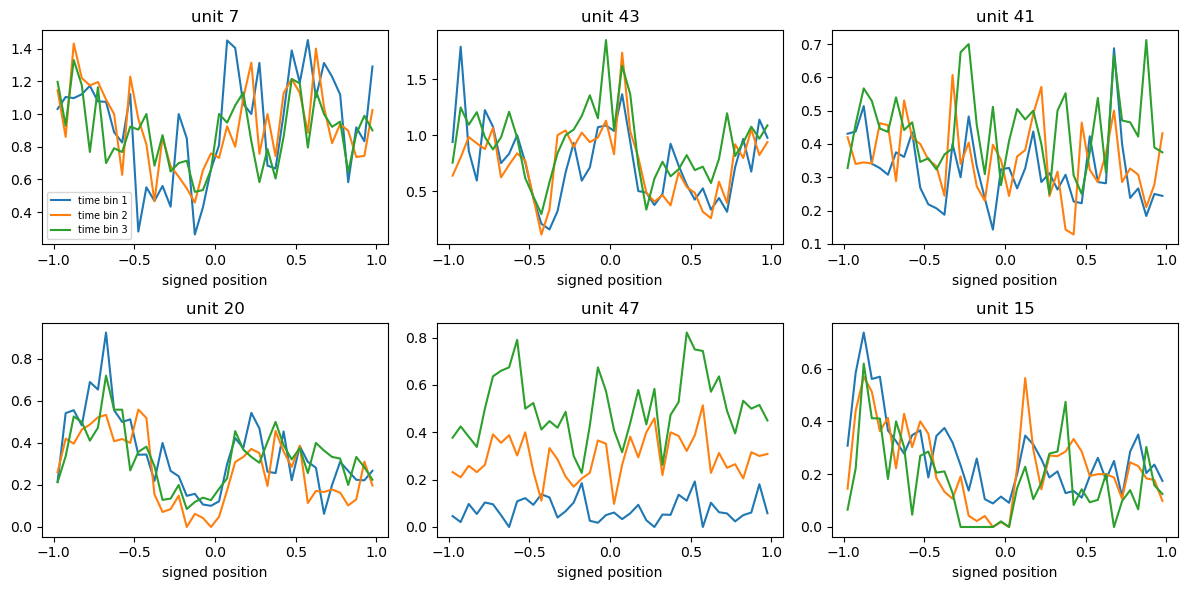

In [14]:
# New Cell 9.5
# diagnostic only: does the conditional mean drift over time?

def drift_mean_curves(Xmat, cov, n_time_bins=3, n_pos_bins=40):
    t = cov["time_norm"].to_numpy()
    s = cov["pos_smooth"].to_numpy() * cov["direction"].to_numpy()

    t_edges = np.linspace(0, 1, n_time_bins + 1)
    s_edges = np.linspace(-1, 1, n_pos_bins + 1)
    s_centers = 0.5 * (s_edges[:-1] + s_edges[1:])

    out = []
    for k in range(n_time_bins):
        mt = (t >= t_edges[k]) & (t < t_edges[k+1] if k < n_time_bins - 1 else t <= t_edges[k+1])
        M = np.full((n_pos_bins, Xmat.shape[1]), np.nan)
        for b in range(n_pos_bins):
            ms = (s >= s_edges[b]) & (s < s_edges[b+1] if b < n_pos_bins - 1 else s <= s_edges[b+1])
            m = mt & ms
            if m.sum() > 0:
                M[b] = Xmat[m].mean(axis=0)
        out.append(M)
    return s_centers, out

s_centers, drift_curves = drift_mean_curves(X_test, cov_test, n_time_bins=3, n_pos_bins=40)

top_units = np.argsort(X_test.mean(axis=0))[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

for ax, j in zip(axes, top_units):
    for k, M in enumerate(drift_curves):
        ax.plot(s_centers, M[:, j], label=f"time bin {k+1}")
    ax.set_title(f"unit {j}")
    ax.set_xlabel("signed position")

axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

,Model,ResidualCorrNorm,AbsErrorToTrue
0,True,1.407237,0.000000
1,MLP mean,0.000000,1.407237
2,Poisson MLP,0.170417,1.452503
3,"count-FM, w=1",0.763858,1.159143
4,"count-FM, w=2",1.056201,1.176978


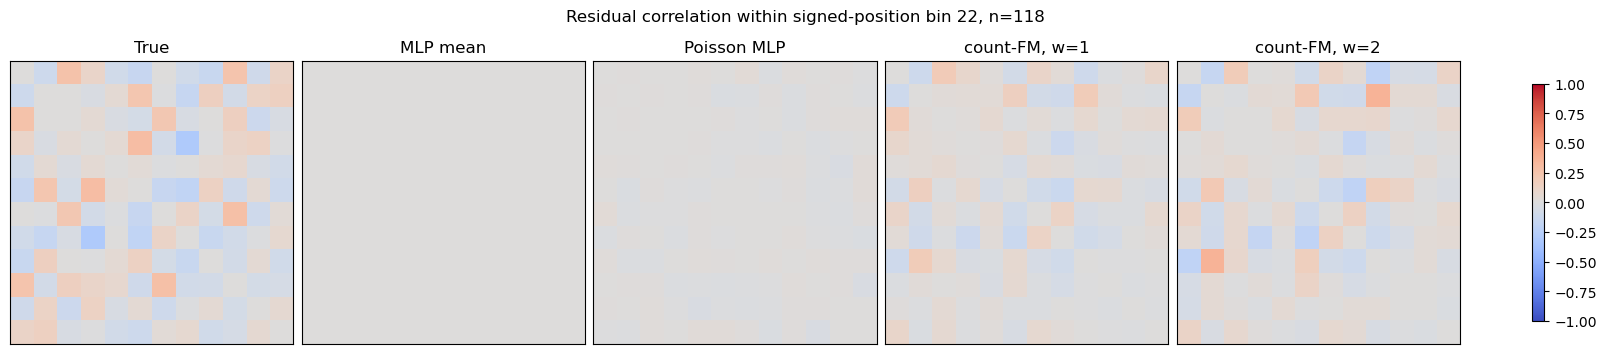

In [15]:
# New Cell 9.5
# expose what MLP / Poisson MLP cannot model: residual joint dependence

def _row_resid_corr(Z, eps=1e-8):
    if Z.shape[0] < 5:
        return None
    Z = Z - Z.mean(axis=0, keepdims=True)
    sd = Z.std(axis=0, ddof=0)
    keep = sd > eps
    if keep.sum() < 2:
        return None
    Z = Z[:, keep] / sd[keep][None, :]
    C = (Z.T @ Z) / Z.shape[0]
    np.fill_diagonal(C, 0.0)
    return C

def _draw_resid_corr(draws, mean_hat, mask, unit_ids):
    R = draws[:, mask][:, :, unit_ids].astype(float)
    M = mean_hat[mask][:, unit_ids].astype(float)
    Z = R - M[None, :, :]
    Z = Z.reshape(-1, len(unit_ids))
    C = _row_resid_corr(Z)
    if C is None:
        return np.zeros((len(unit_ids), len(unit_ids)))
    return C

def _true_resid_corr(Xtrue, mask, unit_ids):
    Z = Xtrue[mask][:, unit_ids].astype(float)
    C = _row_resid_corr(Z)
    if C is None:
        return np.zeros((len(unit_ids), len(unit_ids)))
    return C

# choose informative units
unit_ids = np.argsort(X_test.mean(axis=0))[::-1][:12]

# choose a bin where true residual correlation is strong
s = signed_pos_from_cov(cov_test)
edges = np.linspace(-1.0, 1.0, N_BINS + 1)

best_b = None
best_score = -np.inf

for b in range(N_BINS):
    mask = (s >= edges[b]) & (s < edges[b+1] if b < N_BINS - 1 else s <= edges[b+1])
    if mask.sum() < 80:
        continue
    C = _true_resid_corr(X_test, mask, unit_ids)
    score = np.linalg.norm(C, ord="fro")
    if score > best_score:
        best_score = score
        best_b = b

mask = (s >= edges[best_b]) & (s < edges[best_b+1] if best_b < N_BINS - 1 else s <= edges[best_b+1])

C_true = _true_resid_corr(X_test, mask, unit_ids)

# deterministic MLP has no generative residual noise
C_mlp = np.zeros_like(C_true)

C_pois = _draw_resid_corr(
    pred_draws["Poisson MLP"],
    pred_mean["Poisson MLP"],
    mask,
    unit_ids,
)

C_fm1 = _draw_resid_corr(
    pred_draws["count-FM, w=1"],
    pred_mean["count-FM, w=1"],
    mask,
    unit_ids,
)

C_fm2 = _draw_resid_corr(
    pred_draws["count-FM, w=2"],
    pred_mean["count-FM, w=2"],
    mask,
    unit_ids,
)

corr_mats = {
    "True": C_true,
    "MLP mean": C_mlp,
    "Poisson MLP": C_pois,
    "count-FM, w=1": C_fm1,
    "count-FM, w=2": C_fm2,
}

rows = []
for name, C in corr_mats.items():
    rows.append({
        "Model": name,
        "ResidualCorrNorm": np.linalg.norm(C, ord="fro"),
        "AbsErrorToTrue": np.linalg.norm(C - C_true, ord="fro") if name != "True" else 0.0,
    })

resid_corr_df = pd.DataFrame(rows)
display(resid_corr_df)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), constrained_layout=True)

for ax, (name, C) in zip(axes, corr_mats.items()):
    im = ax.imshow(C, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.8)
fig.suptitle(
    f"Residual correlation within signed-position bin {best_b}, n={mask.sum()}",
    y=1.08,
)
plt.show()

Selected units by region:


,unit_id,region,ele,clu,spatial_info,peak_ratio,stability,n_spikes
0,52,CA1,8,5,1.867734,7.016982,0.937964,229
1,48,CA1,7,12,1.651303,10.117215,0.678061,104
2,42,CA1,6,11,1.366503,7.903061,0.936367,1348
3,28,CA1,5,10,1.172143,7.007889,0.481936,1419
4,6,EC2,1,11,0.894066,9.120621,0.835174,221
5,2,EC2,1,5,0.701066,4.095493,0.711479,167
6,5,EC2,1,8,0.451062,4.102910,0.843260,457
7,12,EC3,2,11,0.795921,5.393149,0.392910,246
8,21,EC5,4,8,0.854982,5.353308,0.871548,2589
9,59,CA1,8,14,1.117443,9.472953,0.921405,483


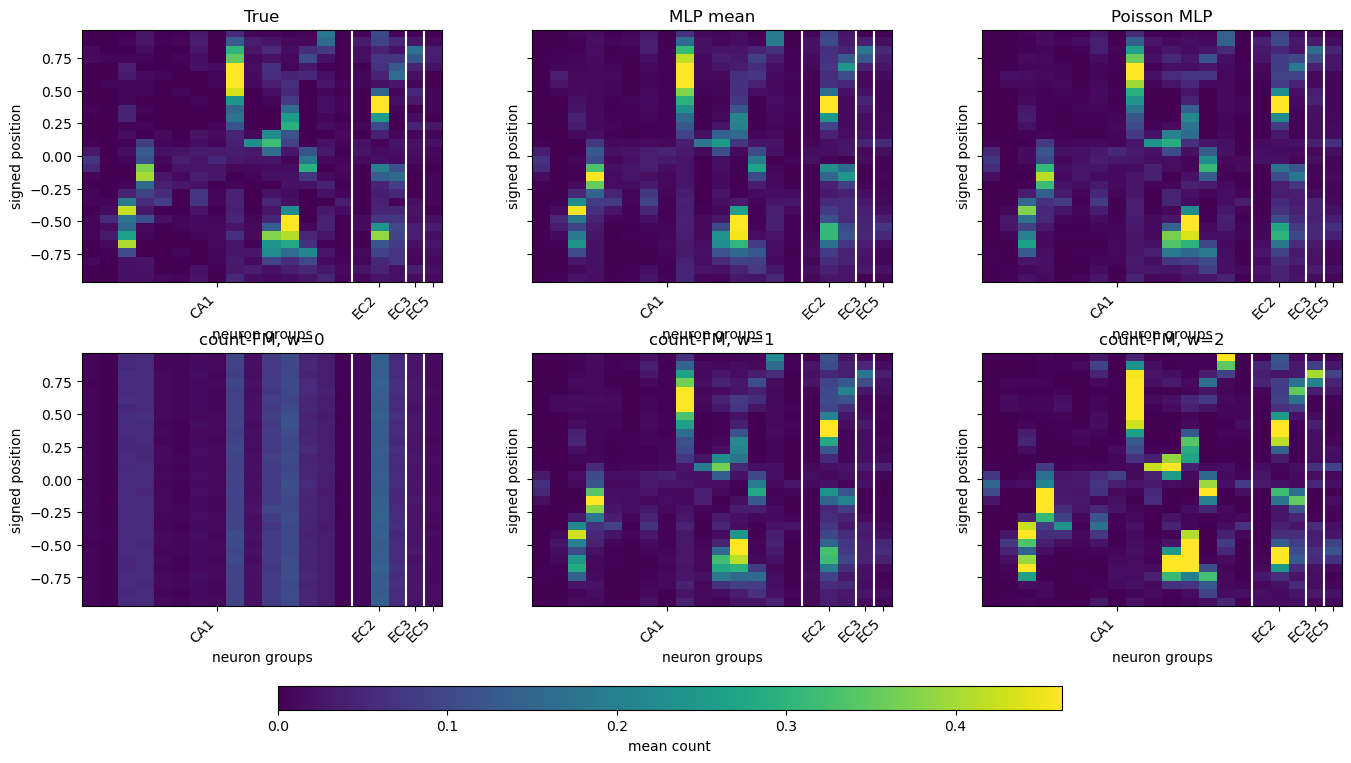

In [16]:
# Cell 10
# mean heatmaps under signed position, using position-specific neurons grouped by region
# self-contained, no hidden dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def signed_pos_from_cov(cov):
    return cov["pos_smooth"].to_numpy() * cov["direction"].to_numpy()

def position_specific_scores(Xmat, cov, unit_meta_local, n_bins=N_BINS, min_occ=20):
    s = signed_pos_from_cov(cov)
    edges = np.linspace(-1.0, 1.0, n_bins + 1)
    n_units = Xmat.shape[1]

    occ = np.zeros(n_bins, dtype=float)
    tc = np.full((n_bins, n_units), np.nan)

    for b in range(n_bins):
        m = (s >= edges[b]) & (s < edges[b+1] if b < n_bins - 1 else s <= edges[b+1])
        occ[b] = m.sum()
        if occ[b] >= min_occ:
            tc[b] = Xmat[m].mean(axis=0)

    occ_prob = occ / np.maximum(occ.sum(), 1.0)

    mean_rate = np.nansum(occ_prob[:, None] * tc, axis=0)
    ratio = tc / (mean_rate[None, :] + 1e-12)
    spatial_info = np.nansum(occ_prob[:, None] * ratio * np.log2(ratio + 1e-12), axis=0)
    spatial_info[~np.isfinite(spatial_info)] = 0.0

    peak_ratio = np.nanmax(tc, axis=0) / (mean_rate + 1e-12)
    peak_ratio[~np.isfinite(peak_ratio)] = 0.0

    # split-half stability on training set
    if "time_norm" in cov.columns:
        tt = cov["time_norm"].to_numpy()
        m1 = tt < np.median(tt)
        m2 = tt >= np.median(tt)
    else:
        n = len(cov)
        m1 = np.arange(n) < (n // 2)
        m2 = ~m1

    def tuning_half(mask_half):
        out = np.full((n_bins, n_units), np.nan)
        for b in range(n_bins):
            mb = mask_half & (s >= edges[b]) & (s < edges[b+1] if b < n_bins - 1 else s <= edges[b+1])
            if mb.sum() >= max(5, min_occ // 2):
                out[b] = Xmat[mb].mean(axis=0)
        return out

    tc1 = tuning_half(m1)
    tc2 = tuning_half(m2)

    stability = np.full(n_units, np.nan)
    for j in range(n_units):
        a = tc1[:, j]
        b = tc2[:, j]
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() >= 5 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
            stability[j] = np.corrcoef(a[m], b[m])[0, 1]

    score_df = unit_meta_local.copy().reset_index(drop=True).copy()
    score_df["unit_id"] = np.arange(n_units)
    score_df["n_spikes"] = Xmat.sum(axis=0)
    score_df["spatial_info"] = spatial_info
    score_df["peak_ratio"] = peak_ratio
    score_df["stability"] = stability
    return score_df

def choose_units_grouped_by_region(
    score_df,
    total_k=20,
    per_region=4,
    min_spikes=30,
    min_peak_ratio=3.0,
    min_stability=0.3,
):
    df = score_df.copy()

    keep = (
        (df["n_spikes"] >= min_spikes) &
        (df["peak_ratio"] >= min_peak_ratio) &
        (df["stability"].fillna(-1) >= min_stability)
    )
    df = df.loc[keep].copy()

    if "region" not in df.columns:
        df["region"] = "Unknown"

    df = df.sort_values(
        ["spatial_info", "peak_ratio", "stability", "n_spikes"],
        ascending=False
    ).reset_index(drop=True)

    region_order = ["CA1", "CA3", "DG", "EC2", "EC3", "EC4", "EC5"]
    existing = [r for r in region_order if r in set(df["region"].astype(str))]
    extras = [r for r in df["region"].astype(str).unique().tolist() if r not in existing]
    region_order = existing + extras

    chosen = []
    for region in region_order:
        sub = df[df["region"].astype(str) == region].head(per_region)
        ids = sub["unit_id"].astype(int).tolist()
        chosen.extend(ids)

    if len(chosen) < total_k:
        remaining = df.loc[~df["unit_id"].isin(chosen), "unit_id"].astype(int).tolist()
        chosen.extend(remaining[: max(0, total_k - len(chosen))])

    chosen = chosen[:total_k]

    chosen_df = df.set_index("unit_id").loc[chosen].reset_index()

    group_info = []
    for region in region_order:
        n_region = int((chosen_df["region"].astype(str) == region).sum())
        if n_region > 0:
            group_info.append((region, n_region))

    return chosen, group_info, chosen_df

score_df = position_specific_scores(X_train, cov_train, unit_meta, n_bins=N_BINS, min_occ=20)

top_units, group_info, chosen_df = choose_units_grouped_by_region(
    score_df,
    total_k=min(20, d),
    per_region=4,
    min_spikes=30,
    min_peak_ratio=3.0,
    min_stability=0.3,
)

print("Selected units by region:")
display(chosen_df[["unit_id", "region", "ele", "clu", "spatial_info", "peak_ratio", "stability", "n_spikes"]])

show_stats = {"True": true_stats["mean"]}
for name, Xhat in pred_mean.items():
    _, _, st = binned_stats(Xhat, cov_test, n_bins=N_BINS)
    show_stats[name] = st["mean"]

vmax = np.nanpercentile(show_stats["True"][:, top_units], 99)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.ravel()

bounds = []
centers_x = []
cursor = 0
for region, n_region in group_info:
    centers_x.append((cursor + 0.5 * n_region, region))
    cursor += n_region
    bounds.append(cursor)
bounds = bounds[:-1]

im = None
for ax, (name, A) in zip(axes, show_stats.items()):
    im = ax.imshow(
        A[:, top_units],
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=vmax,
        extent=[0, len(top_units), centers[0], centers[-1]],
    )
    ax.set_title(name)
    ax.set_xlabel("neuron groups")
    ax.set_ylabel("signed position")

    for b in bounds:
        ax.axvline(b, color="white", linewidth=1.5)

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right")

fig.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.20, wspace=0.25, hspace=0.28)
cax = fig.add_axes([0.22, 0.07, 0.56, 0.03])
cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
cbar.set_label("mean count")

plt.show()

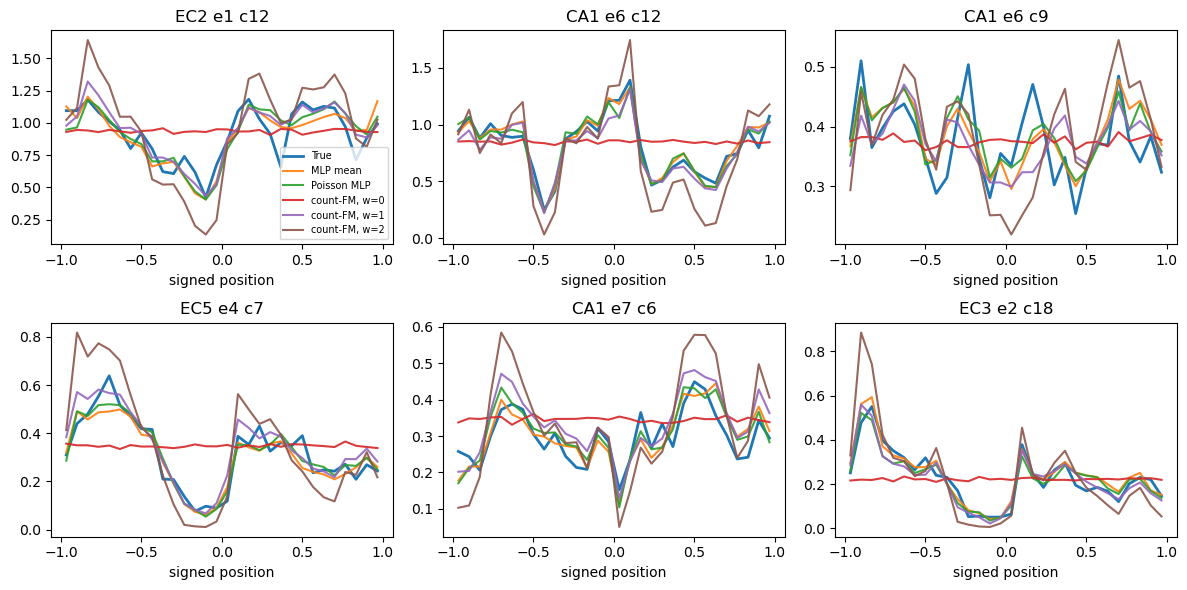

In [17]:
# Cell 11
# a few signed-position tuning curves from the new mean summaries

top_units_small = np.argsort(X_test.mean(axis=0))[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

model_order = ["MLP mean", "Poisson MLP", "count-FM, w=0", "count-FM, w=1", "count-FM, w=2"]

for ax, j in zip(axes, top_units_small):
    ax.plot(centers, true_stats["mean"][:, j], label="True", linewidth=2)

    for name in model_order:
        _, _, st = binned_stats(pred_mean[name], cov_test, n_bins=N_BINS)
        ax.plot(centers, st["mean"][:, j], label=name, alpha=0.9)

    meta = unit_meta.iloc[j]
    title = f"{meta['region']} e{int(meta['ele'])} c{int(meta['clu'])}" if {"region","ele","clu"}.issubset(unit_meta.columns) else f"unit {j}"
    ax.set_title(title)
    ax.set_xlabel("signed position")

axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

In [18]:
# Cell 12
print({
    "train_shape": X_train.shape,
    "test_shape": X_test.shape,
    "model_covariates": ["pos_smooth", "direction"],
    "split_covariate_only": ["time_norm"],
    "mean_eval": ["RMSE_mean"],
    "distribution_eval": ["RMSE_mean", "RMSE_var", "RMSE_zero", "Corr_Frob"],
})

{'train_shape': (23391, 62), 'test_shape': (5848, 62), 'model_covariates': ['pos_smooth', 'direction'], 'split_covariate_only': ['time_norm'], 'mean_eval': ['RMSE_mean'], 'distribution_eval': ['RMSE_mean', 'RMSE_var', 'RMSE_zero', 'Corr_Frob']}


In [19]:
# new diagnostic: per-neuron place-field sharpness across position bins

def halfmax_width(v):
    lo = np.nanmin(v)
    hi = np.nanmax(v)
    thr = lo + 0.5 * (hi - lo)
    return int(np.sum(v >= thr))

def tuning_diag(M, T, centers, active_thresh=0.02):
    active = X_test.mean(axis=0) > active_thresh
    M = M[:, active]
    T = T[:, active]

    peak_loc_err = []
    contrast_raw = []
    contrast_err = []
    width_raw = []
    width_err = []

    for j in range(M.shape[1]):
        m = M[:, j]
        t = T[:, j]
        if not (np.isfinite(m).all() and np.isfinite(t).all()):
            continue

        pm = centers[np.argmax(m)]
        pt = centers[np.argmax(t)]
        peak_loc_err.append(abs(pm - pt))

        cm = (np.max(m) - np.median(m)) / (np.mean(m) + 1e-8)
        ct = (np.max(t) - np.median(t)) / (np.mean(t) + 1e-8)
        contrast_raw.append(cm)
        contrast_err.append(abs(cm - ct))

        wm = halfmax_width(m)
        wt = halfmax_width(t)
        width_raw.append(wm)
        width_err.append(abs(wm - wt))

    return pd.Series({
        "peak_loc_err": np.mean(peak_loc_err),
        "contrast_raw": np.mean(contrast_raw),
        "contrast_err": np.mean(contrast_err),
        "halfmax_width_raw": np.mean(width_raw),
        "halfmax_width_err": np.mean(width_err),
    })

_, _, st1 = avg_stats_over_draws(pred_draws["count-FM, w=1"], cov_test, n_bins=N_BINS)
_, _, st2 = avg_stats_over_draws(pred_draws["count-FM, w=2"], cov_test, n_bins=N_BINS)

diag_w1 = tuning_diag(st1["mean"], true_stats["mean"], centers)
diag_w2 = tuning_diag(st2["mean"], true_stats["mean"], centers)

display(pd.DataFrame({"w=1": diag_w1, "w=2": diag_w2}))

,w=1,w=2
peak_loc_err,0.283333,0.380952
contrast_raw,3.214597,4.611554
contrast_err,0.486484,1.403124
halfmax_width_raw,7.714286,6.071429
halfmax_width_err,1.750000,2.107143


# Output results...

In [20]:
# Output results... Cell 1
# config + helpers for paper outputs with outer-seed training and inner-seed evaluation

from pathlib import Path
import random
import copy

PAPER_DIR = Path("hc3_paper")
FIG_DIR = PAPER_DIR / "figures"
TAB_DIR = PAPER_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

OUTER_SEEDS = [0, 1, 2, 3, 4]          # split + init + training
INNER_EVAL_SEEDS = [0, 1, 2]           # generation/evaluation seeds per trained model
REP_OUTER_SEED = 0
REP_EVAL_SEED = 0

TRAIN_IF_MISSING = True               # set True the first time to create missing checkpoints

MODEL_ORDER = [
    "MLP mean",
    "Poisson MLP",
    "count-FM, w=0",
    "count-FM, w=1",
    "count-FM, w=2",
]

TABLE_METRICS = [
    "RMSE_mean",
    "RMSE_var",
    "RMSE_zero",
    "Cov_Frob",
    "peak_loc_err",
    "contrast_raw",
    "contrast_err",
]

N_REP_MEAN_TABLE = 50
KEEP_DRAWS_TABLE = 50
REP_BATCH_TABLE = 10

N_REP_MEAN_FIG = 100
KEEP_DRAWS_FIG = 100
REP_BATCH_FIG = 10

ACTIVE_THRESH = 0.02
COV_N_BINS = 20
COV_MIN_COUNT = 80

UNIT_META_ALL = unit_meta.copy()
X_BASE = X.copy()
COV_BASE = cov_df.copy()

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def paper_ckpt_path(seed):
    p = CKPT_DIR / f"hc3_models_paper_seed{seed}.pt"
    if seed == 0 and not p.exists() and CKPT_PATH.exists():
        return CKPT_PATH
    return p

def build_outer_split(seed):
    pos = 2.0 * COV_BASE["pos_smooth"].to_numpy(dtype=np.float32) - 1.0
    dir01 = (COV_BASE["direction"].to_numpy() > 0).astype(np.float32)
    y_all = np.stack([pos, dir01], axis=1)

    idx_pos = np.where(COV_BASE["direction"].to_numpy() == 1)[0]
    idx_neg = np.where(COV_BASE["direction"].to_numpy() == -1)[0]

    rng = np.random.default_rng(seed)
    rng.shuffle(idx_pos)
    rng.shuffle(idx_neg)

    ntr_pos = int(0.8 * len(idx_pos))
    ntr_neg = int(0.8 * len(idx_neg))

    train_idx = np.sort(np.concatenate([idx_pos[:ntr_pos], idx_neg[:ntr_neg]]))
    test_idx  = np.sort(np.concatenate([idx_pos[ntr_pos:], idx_neg[ntr_neg:]]))

    return {
        "seed": seed,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "X_train": X_BASE[train_idx],
        "X_test": X_BASE[test_idx],
        "y_train": y_all[train_idx],
        "y_test": y_all[test_idx],
        "cov_train": COV_BASE.iloc[train_idx].reset_index(drop=True),
        "cov_test": COV_BASE.iloc[test_idx].reset_index(drop=True),
    }

def init_models_for_split(c_dim, d):
    mlp = CondMLP(c_dim, d, width=128).to(device)
    pois = PoissonMLP(c_dim, d, width=128).to(device)
    fm = CountFMNetAux(d=d, c_dim_cfg=c_dim + 1, width=128, log_cap=5.0).to(device)
    return mlp, pois, fm

def load_or_train_outer_seed(seed, split, train_if_missing=False):
    set_all_seeds(seed)

    d_local = split["X_train"].shape[1]
    c_dim_local = split["y_train"].shape[1]
    mlp, pois, fm = init_models_for_split(c_dim_local, d_local)
    x0_rate_local = float(split["X_train"].mean())

    ckpt_path = paper_ckpt_path(seed)
    if ckpt_path.exists():
        mlp, pois, fm, x0_loaded, meta = load_hc3_checkpoint(
            ckpt_path,
            mlp_mean=mlp,
            pois_mlp=pois,
            fm_net=fm,
            map_location=device,
        )
        return mlp, pois, fm, float(x0_loaded), ckpt_path, meta

    if not train_if_missing:
        raise FileNotFoundError(
            f"Missing checkpoint for outer seed {seed}: {ckpt_path}\n"
            f"Set TRAIN_IF_MISSING=True to create it."
        )

    Xtr_local = torch.tensor(split["X_train"], dtype=torch.float32, device=device)
    ytr_local = torch.tensor(split["y_train"], dtype=torch.float32, device=device)

    mlp = train_mean_mlp(
        mlp, Xtr_local, ytr_local,
        epochs=1000, batch_size=512, lr=1e-3,
    )
    pois = train_poisson_mlp(
        pois, Xtr_local, ytr_local,
        epochs=1000, batch_size=512, lr=1e-3,
    )
    fm = train_countfm_cond(
        fm, Xtr_local, ytr_local,
        epochs=5000,
        batch_size=512,
        lr=5e-4,
        x0_rate=x0_rate_local,
        p_uncond=0.1,
        lambda_mean=0.1,
    )

    save_hc3_checkpoint(
        ckpt_path,
        mlp_mean=mlp,
        pois_mlp=pois,
        fm_net=fm,
        x0_rate=x0_rate_local,
        meta={
            "outer_seed": seed,
            "epochs": 1000,
            "batch_size": 512,
            "mlp_lr": 1e-3,
            "fm_lr": 5e-4,
            "p_uncond": 0.1,
            "lambda_mean": 0.1,
            "y_dim": int(c_dim_local),
            "d": int(d_local),
        },
    )
    return mlp, pois, fm, x0_rate_local, ckpt_path, {"outer_seed": seed}

@torch.no_grad()
def predict_all_for_split(
    mlp_mean_local,
    pois_mlp_local,
    fm_net_local,
    split,
    x0_rate_local,
    eval_seed,
    n_rep_mean=50,
    keep_draws=50,
    rep_batch=10,
):
    set_all_seeds(eval_seed)

    yte_local = torch.tensor(split["y_test"], dtype=torch.float32, device=device)
    d_local = split["X_test"].shape[1]

    pred_mean_local = {}
    pred_draws_local = {}

    pred_mean_local["MLP mean"] = F.softplus(mlp_mean_local(yte_local)).detach().cpu().numpy()

    rate_pois = pois_mlp_local(yte_local).detach().cpu().numpy()
    pred_mean_local["Poisson MLP"] = rate_pois
    pred_draws_local["Poisson MLP"] = np.random.poisson(
        rate_pois[None, :, :],
        size=(keep_draws, rate_pois.shape[0], rate_pois.shape[1]),
    )

    for w in [0, 1, 2]:
        sum_x = np.zeros((split["y_test"].shape[0], d_local), dtype=np.float64)
        kept = []
        n_done = 0
        n_kept = 0

        while n_done < n_rep_mean:
            b = min(rep_batch, n_rep_mean - n_done)
            xs = sample_countfm_cfg_batch(
                fm_net_local,
                yte_local,
                d=d_local,
                x0_rate=x0_rate_local,
                n_rep=b,
                n_step=1000,
                w=float(w),
            ).cpu().numpy()

            sum_x += xs.sum(axis=0)
            n_done += b

            if n_kept < keep_draws:
                take = min(b, keep_draws - n_kept)
                kept.append(xs[:take])
                n_kept += take

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        pred_mean_local[f"count-FM, w={w}"] = sum_x / n_rep_mean
        pred_draws_local[f"count-FM, w={w}"] = np.concatenate(kept, axis=0)

    return pred_mean_local, pred_draws_local

def offdiag_cov_rows(Xmat):
    if Xmat.shape[0] < 3:
        return None
    C = np.cov(Xmat, rowvar=False)
    if C.ndim != 2 or not np.all(np.isfinite(C)):
        return None
    np.fill_diagonal(C, 0.0)
    return C

def cov_error_from_samples(samples, Xtrue, cov, unit_ids, n_bins=20, min_count=80):
    s = signed_pos_from_cov(cov)
    edges = np.linspace(-1.0, 1.0, n_bins + 1)

    num = 0.0
    den = 0.0

    for b in range(n_bins):
        m = (s >= edges[b]) & (s < edges[b + 1] if b < n_bins - 1 else s <= edges[b + 1])
        nb = int(m.sum())
        if nb < min_count:
            continue

        Ct = offdiag_cov_rows(Xtrue[m][:, unit_ids])
        if Ct is None:
            continue

        if samples.ndim == 2:
            Xg = samples[m][:, unit_ids]
        else:
            Xg = samples[:, m][:, :, unit_ids].reshape(-1, len(unit_ids))

        Cg = offdiag_cov_rows(Xg)
        if Cg is None or Cg.shape != Ct.shape:
            continue

        num += nb * np.linalg.norm(Cg - Ct, ord="fro")
        den += nb

    return float(num / max(den, 1.0))

def tuning_metrics_from_binned_mean(mean_mat, true_mean_mat, centers_vec, active_ids):
    peak_loc_err = []
    contrast_raw = []
    contrast_err = []

    for j in active_ids:
        m = mean_mat[:, j]
        t = true_mean_mat[:, j]
        if not (np.isfinite(m).all() and np.isfinite(t).all()):
            continue

        pm = centers_vec[np.argmax(m)]
        pt = centers_vec[np.argmax(t)]
        peak_loc_err.append(abs(pm - pt))

        cm = (np.max(m) - np.median(m)) / (np.mean(m) + 1e-8)
        ct = (np.max(t) - np.median(t)) / (np.mean(t) + 1e-8)
        contrast_raw.append(cm)
        contrast_err.append(abs(cm - ct))

    return {
        "peak_loc_err": float(np.mean(peak_loc_err)),
        "contrast_raw": float(np.mean(contrast_raw)),
        "contrast_err": float(np.mean(contrast_err)),
    }

def ordered_active_units(active_ids, true_mean_mat, unit_meta_local):
    df = unit_meta_local.iloc[active_ids].copy().reset_index(drop=True)
    df["unit_id"] = active_ids
    df["peak_bin"] = np.argmax(true_mean_mat[:, active_ids], axis=0)

    if "region" in df.columns:
        region_order = ["CA1", "CA3", "DG", "EC2", "EC3", "EC4", "EC5"]
        region_to_rank = {r: i for i, r in enumerate(region_order)}
        df["region_rank"] = df["region"].astype(str).map(region_to_rank).fillna(999)

        sort_cols = ["region_rank", "peak_bin"]
        if "ele" in df.columns:
            sort_cols.append("ele")
        if "clu" in df.columns:
            sort_cols.append("clu")

        df = df.sort_values(sort_cols).reset_index(drop=True)

        group_info = []
        for r in region_order + sorted([x for x in df["region"].astype(str).unique() if x not in region_order]):
            n_r = int((df["region"].astype(str) == r).sum())
            if n_r > 0:
                group_info.append((r, n_r))
    else:
        df = df.sort_values(["peak_bin"]).reset_index(drop=True)
        group_info = [("active", len(df))]

    return df["unit_id"].astype(int).to_numpy(), group_info, df

def stack_binned_residuals_mean(Xmat, mean_mat, cov, unit_ids, n_bins=20, min_count=80):
    s = signed_pos_from_cov(cov)
    edges = np.linspace(-1.0, 1.0, n_bins + 1)
    chunks = []

    for b in range(n_bins):
        m = (s >= edges[b]) & (s < edges[b + 1] if b < n_bins - 1 else s <= edges[b + 1])
        if int(m.sum()) < min_count:
            continue
        mu_b = mean_mat[b, unit_ids]
        if not np.all(np.isfinite(mu_b)):
            continue
        chunks.append(Xmat[m][:, unit_ids] - mu_b[None, :])

    if len(chunks) == 0:
        return np.zeros((0, len(unit_ids)))
    return np.concatenate(chunks, axis=0)

def stack_binned_residuals_draws(draws, mean_mat, cov, unit_ids, n_bins=20, min_count=80):
    s = signed_pos_from_cov(cov)
    edges = np.linspace(-1.0, 1.0, n_bins + 1)
    chunks = []

    for b in range(n_bins):
        m = (s >= edges[b]) & (s < edges[b + 1] if b < n_bins - 1 else s <= edges[b + 1])
        if int(m.sum()) < min_count:
            continue
        mu_b = mean_mat[b, unit_ids]
        if not np.all(np.isfinite(mu_b)):
            continue
        G = draws[:, m][:, :, unit_ids].reshape(-1, len(unit_ids))
        chunks.append(G - mu_b[None, :])

    if len(chunks) == 0:
        return np.zeros((0, len(unit_ids)))
    return np.concatenate(chunks, axis=0)

def corr_from_rows_fixed(Z, eps=1e-8):
    if Z.shape[0] < 5:
        return None
    Zc = Z - Z.mean(axis=0, keepdims=True)
    sd = Zc.std(axis=0, ddof=0)

    Zn = np.zeros_like(Zc)
    keep = sd > eps
    Zn[:, keep] = Zc[:, keep] / sd[keep][None, :]

    C = (Zn.T @ Zn) / Z.shape[0]
    if not np.all(np.isfinite(C)):
        return None
    np.fill_diagonal(C, 0.0)
    return C

def flatten_summary_table(summary_df, metric_cols):
    rows = []
    for model in MODEL_ORDER:
        row = {"Model": model}
        for metric in metric_cols:
            mu = summary_df.loc[model, (metric, "mean")]
            sd = summary_df.loc[model, (metric, "std")]
            if pd.isna(mu):
                row[metric] = "-"
            else:
                row[metric] = f"{mu:.4f} ± {sd:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)

In [21]:
# Output results... Cell 2
# optional: create missing checkpoints for all outer seeds

if TRAIN_IF_MISSING:
    for outer_seed in OUTER_SEEDS:
        print(f"\n===== outer seed {outer_seed} =====")
        split_outer = build_outer_split(outer_seed)
        _ = load_or_train_outer_seed(
            outer_seed,
            split_outer,
            train_if_missing=True,
        )


===== outer seed 0 =====
loaded checkpoint from hc3_ckpts/hc3_models_v1_refined.pt

===== outer seed 1 =====
loaded checkpoint from hc3_ckpts/hc3_models_paper_seed1.pt

===== outer seed 2 =====
loaded checkpoint from hc3_ckpts/hc3_models_paper_seed2.pt

===== outer seed 3 =====
loaded checkpoint from hc3_ckpts/hc3_models_paper_seed3.pt

===== outer seed 4 =====
loaded checkpoint from hc3_ckpts/hc3_models_paper_seed4.pt


In [22]:
# New cell: optionally continue refining paper-output count-FM checkpoints
# Place after Output results... Cell 2, before Output results... Cell 3
# Rerun Output results... Cell 3 and downstream figure cells after this cell

PAPER_DO_REFINE = False   # True: train more; False: skip training but load refined ckpts if present

PAPER_REFINE_EPOCHS = 1000
PAPER_REFINE_BATCH_SIZE = 512
PAPER_REFINE_LR = 1e-4
PAPER_REFINE_P_UNCOND = 0.1
PAPER_REFINE_LAMBDA_MEAN = 0.1

# refine all outer seeds used by the main paper table
# change to [REP_OUTER_SEED] only if you only want representative figures
PAPER_REFINE_SEEDS = OUTER_SEEDS

# preserve the original paper_ckpt_path, even if this cell is run multiple times
if "_paper_ckpt_path_base" not in globals():
    _paper_ckpt_path_base = paper_ckpt_path

def paper_refined_ckpt_path(seed):
    return CKPT_DIR / f"hc3_models_paper_seed{seed}_refined.pt"

if PAPER_DO_REFINE:
    for outer_seed in PAPER_REFINE_SEEDS:
        print(f"\n===== refining outer seed {outer_seed} =====")

        split_outer = build_outer_split(outer_seed)

        d_outer = split_outer["X_train"].shape[1]
        c_dim_outer = split_outer["y_train"].shape[1]

        base_ckpt_path = _paper_ckpt_path_base(outer_seed)
        refined_ckpt_path = paper_refined_ckpt_path(outer_seed)

        start_ckpt_path = refined_ckpt_path if refined_ckpt_path.exists() else base_ckpt_path
        print("loading from:", start_ckpt_path)

        mlp_outer, pois_outer, fm_outer = init_models_for_split(c_dim_outer, d_outer)

        mlp_outer, pois_outer, fm_outer, x0_outer, meta_outer = load_hc3_checkpoint(
            start_ckpt_path,
            mlp_mean=mlp_outer,
            pois_mlp=pois_outer,
            fm_net=fm_outer,
            map_location=device,
        )

        Xtr_outer = torch.tensor(split_outer["X_train"], dtype=torch.float32, device=device)
        ytr_outer = torch.tensor(split_outer["y_train"], dtype=torch.float32, device=device)

        fm_outer.train()

        fm_outer = train_countfm_cond(
            fm_outer,
            Xtr_outer,
            ytr_outer,
            epochs=PAPER_REFINE_EPOCHS,
            batch_size=PAPER_REFINE_BATCH_SIZE,
            lr=PAPER_REFINE_LR,
            x0_rate=x0_outer,
            p_uncond=PAPER_REFINE_P_UNCOND,
            lambda_mean=PAPER_REFINE_LAMBDA_MEAN,
        )

        fm_outer.eval()

        meta_outer = {} if meta_outer is None else dict(meta_outer)
        meta_outer["outer_seed"] = int(outer_seed)
        meta_outer["refine_round"] = int(meta_outer.get("refine_round", 0)) + 1
        meta_outer["extra_countfm_epochs"] = int(meta_outer.get("extra_countfm_epochs", 0)) + PAPER_REFINE_EPOCHS
        meta_outer["last_refine_epochs"] = int(PAPER_REFINE_EPOCHS)
        meta_outer["last_refine_lr"] = float(PAPER_REFINE_LR)
        meta_outer["last_refine_batch_size"] = int(PAPER_REFINE_BATCH_SIZE)
        meta_outer["last_refine_p_uncond"] = float(PAPER_REFINE_P_UNCOND)
        meta_outer["last_refine_lambda_mean"] = float(PAPER_REFINE_LAMBDA_MEAN)

        save_hc3_checkpoint(
            refined_ckpt_path,
            mlp_mean=mlp_outer,
            pois_mlp=pois_outer,
            fm_net=fm_outer,
            x0_rate=x0_outer,
            meta=meta_outer,
        )

        print("saved refined checkpoint:", refined_ckpt_path)
        print("refine round:", meta_outer["refine_round"])
        print("extra count-FM epochs:", meta_outer["extra_countfm_epochs"])

        del mlp_outer, pois_outer, fm_outer, Xtr_outer, ytr_outer

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
else:
    print("\nPAPER_DO_REFINE = False, skipping refined training.")

# make Output results... Cell 3 use refined checkpoints automatically
def paper_ckpt_path(seed):
    refined = paper_refined_ckpt_path(seed)
    if refined.exists():
        return refined
    return _paper_ckpt_path_base(seed)

for outer_seed in PAPER_REFINE_SEEDS:
    print(f"seed {outer_seed} will load:", paper_ckpt_path(outer_seed))

# avoid using stale representative cache after checkpoint-path switch
rep_cache = None

print("\nDone. Output results... Cell 3 and downstream cells will prefer refined checkpoints when available.")


PAPER_DO_REFINE = False, skipping refined training.
seed 0 will load: hc3_ckpts/hc3_models_paper_seed0_refined.pt
seed 1 will load: hc3_ckpts/hc3_models_paper_seed1_refined.pt
seed 2 will load: hc3_ckpts/hc3_models_paper_seed2_refined.pt
seed 3 will load: hc3_ckpts/hc3_models_paper_seed3_refined.pt
seed 4 will load: hc3_ckpts/hc3_models_paper_seed4_refined.pt

Done. Output results... Cell 3 and downstream cells will prefer refined checkpoints when available.


In [23]:
# Output results... Cell 3
# main paper table: mean/std across outer seeds
# for each outer seed, metrics are first averaged across inner eval seeds

outer_metric_rows = []
rep_cache = None

for outer_seed in OUTER_SEEDS:
    split_outer = build_outer_split(outer_seed)
    mlp_outer, pois_outer, fm_outer, x0_outer, ckpt_path_outer, ckpt_meta_outer = load_or_train_outer_seed(
        outer_seed,
        split_outer,
        train_if_missing=TRAIN_IF_MISSING,
    )

    active_ids_outer = np.where(split_outer["X_train"].mean(axis=0) > ACTIVE_THRESH)[0]
    if len(active_ids_outer) < 2:
        active_ids_outer = np.arange(split_outer["X_train"].shape[1])

    inner_rows = []

    for eval_seed in INNER_EVAL_SEEDS:
        pred_mean_eval, pred_draws_eval = predict_all_for_split(
            mlp_mean_local=mlp_outer,
            pois_mlp_local=pois_outer,
            fm_net_local=fm_outer,
            split=split_outer,
            x0_rate_local=x0_outer,
            eval_seed=10000 * (outer_seed + 1) + eval_seed,
            n_rep_mean=N_REP_MEAN_TABLE,
            keep_draws=KEEP_DRAWS_TABLE,
            rep_batch=REP_BATCH_TABLE,
        )

        centers_eval, counts_eval, true_stats_eval = binned_stats(
            split_outer["X_test"],
            split_outer["cov_test"],
            n_bins=N_BINS,
        )

        for name in MODEL_ORDER:
            _, _, st_mean = binned_stats(pred_mean_eval[name], split_outer["cov_test"], n_bins=N_BINS)
            sharp = tuning_metrics_from_binned_mean(
                st_mean["mean"],
                true_stats_eval["mean"],
                centers_eval,
                active_ids_outer,
            )

            row = {
                "outer_seed": outer_seed,
                "eval_seed": eval_seed,
                "Model": name,
                "RMSE_mean": weighted_rmse(st_mean["mean"], true_stats_eval["mean"], counts_eval),
                "peak_loc_err": sharp["peak_loc_err"],
                "contrast_raw": sharp["contrast_raw"],
                "contrast_err": sharp["contrast_err"],
            }

            if name == "MLP mean":
                row["RMSE_var"] = np.nan
                row["RMSE_zero"] = np.nan
                row["Cov_Frob"] = np.nan
            else:
                _, _, st_draw = avg_stats_over_draws(pred_draws_eval[name], split_outer["cov_test"], n_bins=N_BINS)
                row["RMSE_var"] = weighted_rmse(st_draw["var"], true_stats_eval["var"], counts_eval)
                row["RMSE_zero"] = weighted_rmse(st_draw["zero"], true_stats_eval["zero"], counts_eval)
                row["Cov_Frob"] = cov_error_from_samples(
                    pred_draws_eval[name],
                    split_outer["X_test"],
                    split_outer["cov_test"],
                    active_ids_outer,
                    n_bins=COV_N_BINS,
                    min_count=COV_MIN_COUNT,
                )

            inner_rows.append(row)

        if outer_seed == REP_OUTER_SEED and eval_seed == REP_EVAL_SEED:
            rep_cache = {
                "split": split_outer,
                "pred_mean": pred_mean_eval,
                "pred_draws": pred_draws_eval,
                "centers": centers_eval,
                "counts": counts_eval,
                "true_stats": true_stats_eval,
                "active_ids": active_ids_outer,
            }

    inner_df = pd.DataFrame(inner_rows)
    inner_avg_df = (
        inner_df
        .groupby("Model")[TABLE_METRICS]
        .mean()
        .reset_index()
    )
    inner_avg_df["outer_seed"] = outer_seed
    outer_metric_rows.append(inner_avg_df)

paper_outer_df = pd.concat(outer_metric_rows, ignore_index=True)
paper_outer_df["Model"] = pd.Categorical(paper_outer_df["Model"], categories=MODEL_ORDER, ordered=True)
paper_outer_df = paper_outer_df.sort_values(["Model", "outer_seed"]).reset_index(drop=True)

paper_summary_num = (
    paper_outer_df
    .groupby("Model")[TABLE_METRICS]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

paper_summary_pretty = flatten_summary_table(paper_summary_num, TABLE_METRICS)

paper_outer_df.to_csv(TAB_DIR / "hc3_main_table_outer_seed_avg.csv", index=False)
paper_summary_num.to_csv(TAB_DIR / "hc3_main_table_mean_std_numeric.csv")
paper_summary_pretty.to_csv(TAB_DIR / "hc3_main_table_mean_std_pretty.csv", index=False)

with open(TAB_DIR / "hc3_main_table_mean_std.tex", "w") as f:
    f.write(paper_summary_pretty.to_latex(index=False, escape=False))

display(paper_outer_df)
display(paper_summary_num)
display(paper_summary_pretty)

print(TAB_DIR / "hc3_main_table_outer_seed_avg.csv")
print(TAB_DIR / "hc3_main_table_mean_std_numeric.csv")
print(TAB_DIR / "hc3_main_table_mean_std_pretty.csv")
print(TAB_DIR / "hc3_main_table_mean_std.tex")

loaded checkpoint from hc3_ckpts/hc3_models_paper_seed0_refined.pt
loaded checkpoint from hc3_ckpts/hc3_models_paper_seed1_refined.pt
loaded checkpoint from hc3_ckpts/hc3_models_paper_seed2_refined.pt
loaded checkpoint from hc3_ckpts/hc3_models_paper_seed3_refined.pt
loaded checkpoint from hc3_ckpts/hc3_models_paper_seed4_refined.pt


/tmp/ipykernel_1122910/4093376331.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  paper_outer_df


,Model,RMSE_mean,RMSE_var,RMSE_zero,Cov_Frob,peak_loc_err,contrast_raw,contrast_err,outer_seed
0,MLP mean,0.025296,NaN,NaN,NaN,0.313580,3.079930,0.520618,0
1,MLP mean,0.026990,NaN,NaN,NaN,0.274074,3.099415,0.541859,1
2,MLP mean,0.024954,NaN,NaN,NaN,0.278571,3.038336,0.533271,2
3,MLP mean,0.024818,NaN,NaN,NaN,0.308642,3.131493,0.517632,3
4,MLP mean,0.029531,NaN,NaN,NaN,0.202469,3.085377,0.699993,4
5,Poisson MLP,0.024906,0.110410,0.026830,0.542423,0.254321,3.020320,0.492631,0
6,Poisson MLP,0.028448,0.112218,0.028264,0.571584,0.261728,3.245568,0.377438,1
7,Poisson MLP,0.025002,0.116301,0.026518,0.569389,0.361905,3.156381,0.457635,2
8,Poisson MLP,0.026913,0.117306,0.027201,0.565134,0.407407,3.213076,0.486467,3
9,Poisson MLP,0.027461,0.116094,0.027997,0.569527,0.279012,3.036851,0.499213,4


RMSE_mean            RMSE_var           RMSE_zero            \
                   mean       std      mean       std      mean       std   
Model                                                                       
MLP mean       0.026318  0.001995       NaN       NaN       NaN       NaN   
Poisson MLP    0.026546  0.001554  0.114466  0.002983  0.027362  0.000748   
count-FM, w=0  0.069751  0.001702  0.110361  0.004641  0.043019  0.000366   
count-FM, w=1  0.025649  0.001996  0.048061  0.004894  0.015910  0.000467   
count-FM, w=2  0.061404  0.001927  0.093849  0.007444  0.035531  0.000976   

               Cov_Frob           peak_loc_err           contrast_raw  \
                   mean       std         mean       std         mean   
Model                                                                   
MLP mean            NaN       NaN     0.275467  0.044423     3.086910   
Poisson MLP    0.563611  0.012075     0.312875  0.068065     3.134439   
count-FM, w=0  0.450599  0.020910     0.620864  0.041122     0.109263   
count-FM, w=1  0.343935  0.016775     0.276702  0.042742     3.208824   
count-FM, w=2  0.450503  0.019916     0.255015  0.055706     4.520584   

                        contrast_err            
                    std         mean       std  
Model                                           
MLP mean       0.033744     0.562675  0.077382  
Poisson MLP    0.101933     0.462677  0.050222  
count-FM, w=0  0.006663     3.150412  0.096659  
count-FM, w=1  0.085695     0.524270  0.068204  
count-FM, w=2  0.075598     1.343002  0.151429

,Model,RMSE_mean,RMSE_var,RMSE_zero,Cov_Frob,peak_loc_err,contrast_raw,contrast_err
0,MLP mean,0.0263 ± 0.0020,-,-,-,0.2755 ± 0.0444,3.0869 ± 0.0337,0.5627 ± 0.0774
1,Poisson MLP,0.0265 ± 0.0016,0.1145 ± 0.0030,0.0274 ± 0.0007,0.5636 ± 0.0121,0.3129 ± 0.0681,3.1344 ± 0.1019,0.4627 ± 0.0502
2,"count-FM, w=0",0.0698 ± 0.0017,0.1104 ± 0.0046,0.0430 ± 0.0004,0.4506 ± 0.0209,0.6209 ± 0.0411,0.1093 ± 0.0067,3.1504 ± 0.0967
3,"count-FM, w=1",0.0256 ± 0.0020,0.0481 ± 0.0049,0.0159 ± 0.0005,0.3439 ± 0.0168,0.2767 ± 0.0427,3.2088 ± 0.0857,0.5243 ± 0.0682
4,"count-FM, w=2",0.0614 ± 0.0019,0.0938 ± 0.0074,0.0355 ± 0.0010,0.4505 ± 0.0199,0.2550 ± 0.0557,4.5206 ± 0.0756,1.3430 ± 0.1514


hc3_paper/tables/hc3_main_table_outer_seed_avg.csv
hc3_paper/tables/hc3_main_table_mean_std_numeric.csv
hc3_paper/tables/hc3_main_table_mean_std_pretty.csv
hc3_paper/tables/hc3_main_table_mean_std.tex


In [24]:
# Output results... Cell 4
# representative cache for figures

if rep_cache is None:
    split_rep = build_outer_split(REP_OUTER_SEED)
    mlp_rep, pois_rep, fm_rep, x0_rep, _, _ = load_or_train_outer_seed(
        REP_OUTER_SEED,
        split_rep,
        train_if_missing=TRAIN_IF_MISSING,
    )
    pred_mean_rep, pred_draws_rep = predict_all_for_split(
        mlp_mean_local=mlp_rep,
        pois_mlp_local=pois_rep,
        fm_net_local=fm_rep,
        split=split_rep,
        x0_rate_local=x0_rep,
        eval_seed=10000 * (REP_OUTER_SEED + 1) + REP_EVAL_SEED,
        n_rep_mean=N_REP_MEAN_FIG,
        keep_draws=KEEP_DRAWS_FIG,
        rep_batch=REP_BATCH_FIG,
    )
    centers_rep, counts_rep, true_stats_rep = binned_stats(split_rep["X_test"], split_rep["cov_test"], n_bins=N_BINS)
    active_ids_rep = np.where(split_rep["X_train"].mean(axis=0) > ACTIVE_THRESH)[0]
    if len(active_ids_rep) < 2:
        active_ids_rep = np.arange(split_rep["X_train"].shape[1])

    rep_cache = {
        "split": split_rep,
        "pred_mean": pred_mean_rep,
        "pred_draws": pred_draws_rep,
        "centers": centers_rep,
        "counts": counts_rep,
        "true_stats": true_stats_rep,
        "active_ids": active_ids_rep,
    }

split_rep = rep_cache["split"]
pred_mean_rep = rep_cache["pred_mean"]
pred_draws_rep = rep_cache["pred_draws"]
centers_rep = rep_cache["centers"]
counts_rep = rep_cache["counts"]
true_stats_rep = rep_cache["true_stats"]
active_ids_rep = rep_cache["active_ids"]

print("representative outer seed:", REP_OUTER_SEED)
print("representative eval seed:", REP_EVAL_SEED)
print("active neurons:", len(active_ids_rep))

representative outer seed: 0
representative eval seed: 0
active neurons: 27


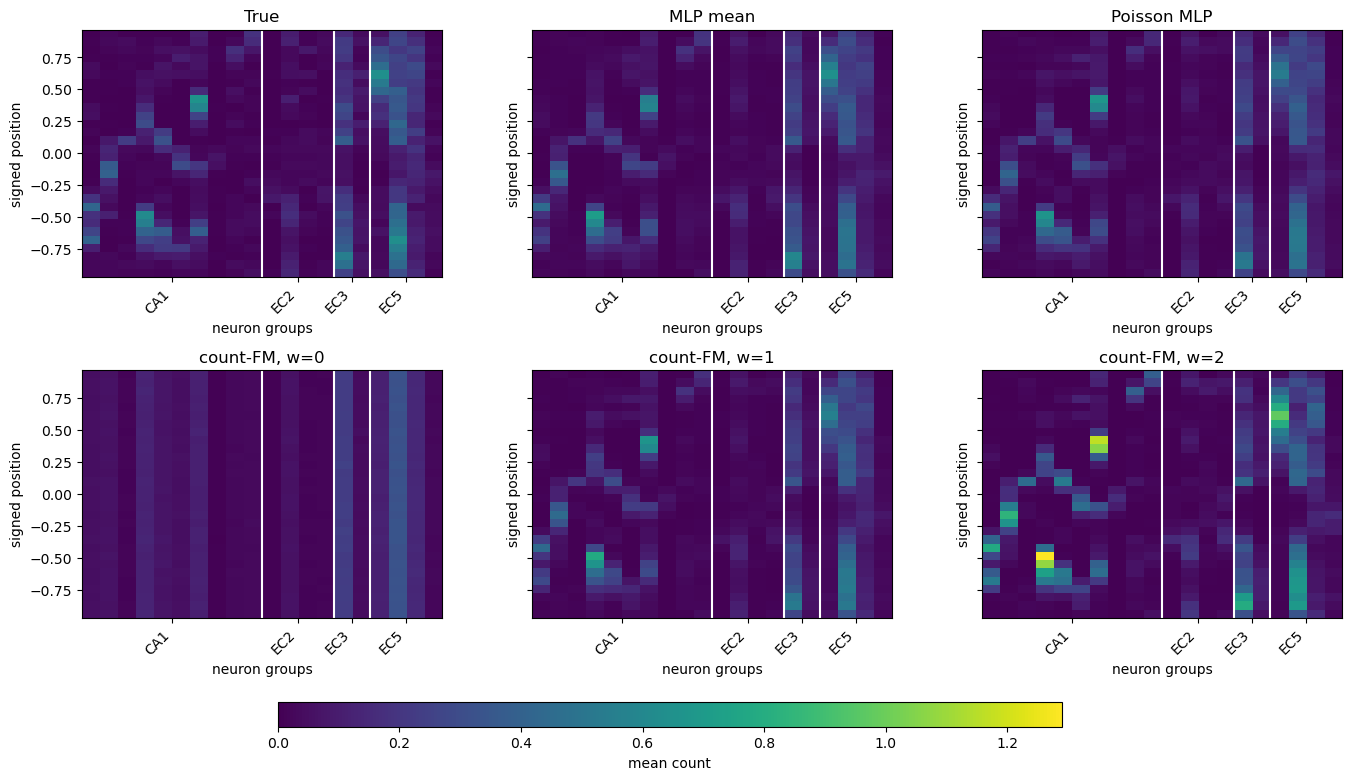

,unit,region,n_spikes,plot_peak,plot_baseline,plot_dynamic,plot_contrast,plot_spatial_info,train_spatial_info,stability,select_score
0,42,CA1,1348,0.424000,0.018959,0.405041,0.955286,1.352258,1.322206,0.936367,7.22
1,28,CA1,1419,0.402778,0.018695,0.384083,0.953585,1.366432,1.277561,0.481936,6.63
2,59,CA1,483,0.229730,0.011398,0.218331,0.950384,1.478653,1.209517,0.921405,6.52
3,60,CA1,2630,0.617021,0.048914,0.568108,0.920726,0.979213,0.982193,0.967857,6.45
4,57,CA1,1616,0.376404,0.027836,0.348569,0.926048,0.986595,1.112922,0.670100,6.00
5,61,CA1,1310,0.295918,0.017573,0.278346,0.940616,1.275789,1.152160,0.646108,5.97
6,49,CA1,2818,0.661017,0.068773,0.592244,0.895959,0.762486,0.652000,0.877658,5.91
7,52,CA1,229,0.070461,0.003208,0.067252,0.954465,1.616447,2.140945,0.937964,5.75
8,35,CA1,683,0.175824,0.020557,0.155268,0.883084,0.820806,0.582078,0.870463,4.71
9,54,CA1,840,0.181818,0.022372,0.159446,0.876952,0.800615,0.767956,0.772176,4.68


hc3_paper/figures/hc3_mean_response_outer0_eval0.pdf
hc3_paper/tables/hc3_mean_heatmap_units_outer0_eval0.csv
selected neurons: 20
shared vmax_rep: 1.289787234042553


In [25]:
# Output results... Cell 5
# Figure 1: mean response heatmaps, saved as PDF
# Shared location-specific neuron selection for Cell 5, Cell 6, Cell 7, and colored heatmap

show_stats_rep = {"True": true_stats_rep["mean"]}
for name in MODEL_ORDER:
    _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)
    show_stats_rep[name] = st["mean"]

# training true tuning, used to evaluate stability and train-side location specificity
_, _, train_stats_for_select = binned_stats(
    split_rep["X_train"],
    split_rep["cov_train"],
    n_bins=N_BINS,
)

def _curve_features_local(M, prefix):
    n_bins, n_units = M.shape
    p = np.ones(n_bins, dtype=float) / n_bins

    peak = np.nanmax(M, axis=0)
    baseline = np.nanmedian(M, axis=0)
    mean_response = np.nanmean(M, axis=0)
    dynamic = peak - baseline
    contrast = dynamic / (peak + 1e-8)
    peak_ratio = peak / (baseline + 1e-8)

    rbar = np.nansum(p[:, None] * M, axis=0)
    ratio = M / (rbar[None, :] + 1e-12)
    spatial_info = np.nansum(
        p[:, None] * ratio * np.log2(ratio + 1e-12),
        axis=0,
    )
    spatial_info[~np.isfinite(spatial_info)] = 0.0

    return pd.DataFrame({
        f"{prefix}_peak": np.nan_to_num(peak, nan=0.0),
        f"{prefix}_baseline": np.nan_to_num(baseline, nan=0.0),
        f"{prefix}_mean_response": np.nan_to_num(mean_response, nan=0.0),
        f"{prefix}_dynamic": np.nan_to_num(dynamic, nan=0.0),
        f"{prefix}_contrast": np.nan_to_num(contrast, nan=0.0),
        f"{prefix}_peak_ratio": np.nan_to_num(peak_ratio, nan=0.0),
        f"{prefix}_spatial_info": np.nan_to_num(spatial_info, nan=0.0),
    })

def _split_half_stability_local(Xmat, cov, n_bins=30, min_occ=20):
    s = cov["pos_smooth"].to_numpy() * cov["direction"].to_numpy()
    edges = np.linspace(-1.0, 1.0, n_bins + 1)
    n_units = Xmat.shape[1]

    if "time_norm" in cov.columns:
        tt = cov["time_norm"].to_numpy()
        m1 = tt < np.median(tt)
        m2 = ~m1
    else:
        n = len(cov)
        m1 = np.arange(n) < n // 2
        m2 = ~m1

    def _half_curve(mask):
        out = np.full((n_bins, n_units), np.nan)

        for b in range(n_bins):
            mb = mask & (s >= edges[b]) & (s < edges[b + 1] if b < n_bins - 1 else s <= edges[b + 1])
            if mb.sum() >= max(5, min_occ // 2):
                out[b] = Xmat[mb].mean(axis=0)

        return out

    C1 = _half_curve(m1)
    C2 = _half_curve(m2)

    stability = np.full(n_units, np.nan)

    for j in range(n_units):
        a = C1[:, j]
        b = C2[:, j]
        ok = np.isfinite(a) & np.isfinite(b)

        if ok.sum() >= 5 and np.std(a[ok]) > 1e-8 and np.std(b[ok]) > 1e-8:
            stability[j] = np.corrcoef(a[ok], b[ok])[0, 1]

    return np.nan_to_num(stability, nan=-1.0)

def _build_selection_df_local(train_mean, plot_mean, Xtrain, cov_train, unit_meta_local):
    n_units = train_mean.shape[1]

    df = pd.DataFrame({
        "unit": np.arange(n_units, dtype=int),
        "unit_id": np.arange(n_units, dtype=int),
        "n_spikes": Xtrain.sum(axis=0),
        "train_mean_count": Xtrain.mean(axis=0),
    })

    df = pd.concat(
        [
            df,
            _curve_features_local(train_mean, "train"),
            _curve_features_local(plot_mean, "plot"),
        ],
        axis=1,
    )

    df["stability"] = _split_half_stability_local(
        Xtrain,
        cov_train,
        n_bins=N_BINS,
        min_occ=20,
    )

    if unit_meta_local is not None and len(unit_meta_local) >= n_units:
        meta = unit_meta_local.reset_index(drop=True)
        for col in ["region", "ele", "clu"]:
            if col in meta.columns:
                df[col] = meta.loc[:n_units - 1, col].to_numpy()

    if "region" not in df.columns:
        df["region"] = "active"

    df["region"] = df["region"].astype(str).str.strip()

    return df

def _choose_units_grouped_local(
    score_df,
    total_k=20,
    per_region=4,
    min_spikes=50,
    min_plot_contrast=0.35,
    min_plot_spatial_info=0.01,
    min_stability=0.05,
):
    df0 = score_df.copy()

    positive_peak = df0.loc[df0["plot_peak"] > 0, "plot_peak"].to_numpy()
    positive_dynamic = df0.loc[df0["plot_dynamic"] > 0, "plot_dynamic"].to_numpy()

    if len(positive_peak) == 0:
        positive_peak = np.array([1.0])
    if len(positive_dynamic) == 0:
        positive_dynamic = np.array([1.0])

    peak_floor = max(0.02, np.nanpercentile(positive_peak, 45))
    dynamic_floor = max(0.01, np.nanpercentile(positive_dynamic, 45))

    # hard filter: visible in the plotted true heatmap and location-specific
    df = df0[
        (df0["n_spikes"] >= min_spikes)
        & (df0["plot_peak"] >= peak_floor)
        & (df0["plot_dynamic"] >= dynamic_floor)
        & (df0["plot_contrast"] >= min_plot_contrast)
        & (df0["plot_spatial_info"] >= min_plot_spatial_info)
        & (df0["stability"] >= min_stability)
    ].copy()

    # relaxed fallback, still avoids silent and flat neurons
    if len(df) < total_k:
        df = df0[
            (df0["n_spikes"] >= min_spikes)
            & (df0["plot_peak"] >= peak_floor)
            & (df0["plot_dynamic"] >= dynamic_floor)
            & (df0["plot_contrast"] >= 0.25)
            & (df0["plot_spatial_info"] > 0)
        ].copy()

    if len(df) < total_k:
        df = df0[
            (df0["plot_peak"] >= peak_floor)
            & (df0["plot_dynamic"] >= dynamic_floor)
            & (df0["plot_contrast"] >= 0.20)
            & (df0["plot_spatial_info"] > 0)
        ].copy()

    if len(df) == 0:
        df = df0.sort_values(
            ["plot_peak", "plot_dynamic", "plot_spatial_info"],
            ascending=False,
        ).head(total_k).copy()

    rank_cols = [
        "plot_spatial_info",
        "plot_contrast",
        "plot_dynamic",
        "plot_peak",
        "train_spatial_info",
        "stability",
    ]

    for col in rank_cols:
        df[col + "_rank"] = df[col].rank(pct=True)

    df["select_score"] = (
        2.5 * df["plot_spatial_info_rank"]
        + 2.0 * df["plot_contrast_rank"]
        + 1.5 * df["plot_dynamic_rank"]
        + 1.0 * df["plot_peak_rank"]
        + 0.75 * df["train_spatial_info_rank"]
        + 0.50 * df["stability_rank"]
    )

    region_order = ["CA1", "CA3", "DG", "EC2", "EC3", "EC4", "EC5"]

    chosen = []
    for r in region_order:
        sub = (
            df[df["region"] == r]
            .sort_values("select_score", ascending=False)
            .head(per_region)
        )

        if len(sub) > 0:
            chosen.append(sub)

    chosen_df = pd.concat(chosen, axis=0) if len(chosen) > 0 else df.head(0).copy()

    if len(chosen_df) < total_k:
        extra = (
            df.loc[~df["unit"].isin(chosen_df["unit"])]
            .sort_values("select_score", ascending=False)
            .head(total_k - len(chosen_df))
        )

        chosen_df = pd.concat([chosen_df, extra], axis=0)

    chosen_df = chosen_df.drop_duplicates(subset=["unit"]).head(total_k).reset_index(drop=True)

    region_rank = {r: i for i, r in enumerate(region_order)}
    chosen_df["region_rank"] = chosen_df["region"].map(region_rank).fillna(999)

    chosen_df = chosen_df.sort_values(
        ["region_rank", "select_score"],
        ascending=[True, False],
    ).reset_index(drop=True)

    group_info = []
    for r in region_order + sorted([x for x in chosen_df["region"].unique() if x not in region_order]):
        n_r = int((chosen_df["region"] == r).sum())
        if n_r > 0:
            group_info.append((r, n_r))

    return chosen_df["unit"].astype(int).to_numpy(), group_info, chosen_df

score_df_rep = _build_selection_df_local(
    train_stats_for_select["mean"],
    show_stats_rep["True"],
    split_rep["X_train"],
    split_rep["cov_train"],
    UNIT_META_ALL,
)

top_units_rep, group_info_rep, chosen_df_rep = _choose_units_grouped_local(
    score_df_rep,
    total_k=min(20, split_rep["X_train"].shape[1]),
    per_region=4,
    min_spikes=50,
    min_plot_contrast=0.35,
    min_plot_spatial_info=0.01,
    min_stability=0.05,
)

# force Cell 6 and Cell 7 to use exactly the same neurons
active_ids_rep = top_units_rep.copy()
if isinstance(rep_cache, dict):
    rep_cache["active_ids"] = active_ids_rep

chosen_units_csv = TAB_DIR / f"hc3_mean_heatmap_units_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.csv"
chosen_df_rep.to_csv(chosen_units_csv, index=False)

panel_order = ["True"] + MODEL_ORDER

vmax_rep = np.nanmax(
    np.stack([show_stats_rep[name][:, top_units_rep] for name in panel_order], axis=0)
)
vmax_rep = vmax_rep if np.isfinite(vmax_rep) and vmax_rep > 0 else 1.0

fig, axes = plt.subplots(2, 3, figsize=(14, 8.4), sharey=True)
axes = axes.ravel()

bounds = []
centers_x = []
cursor = 0

for region, n_region in group_info_rep:
    centers_x.append((cursor + 0.5 * n_region, region))
    cursor += n_region
    bounds.append(cursor)

bounds = bounds[:-1]

im = None

for ax, name in zip(axes, panel_order):
    A = show_stats_rep[name]

    im = ax.imshow(
        A[:, top_units_rep],
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=vmax_rep,
        extent=[0, len(top_units_rep), centers_rep[0], centers_rep[-1]],
    )

    ax.set_title(name)
    ax.set_xlabel("neuron groups")
    ax.set_ylabel("signed position")

    for b in bounds:
        ax.axvline(b, color="white", linewidth=1.5)

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right")

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.92,
    bottom=0.22,
    wspace=0.25,
    hspace=0.38,
)

cax = fig.add_axes([0.22, 0.09, 0.56, 0.03])
cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
cbar.set_label("mean count")

mean_pdf = FIG_DIR / f"hc3_mean_response_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
fig.savefig(mean_pdf, bbox_inches="tight")
plt.show()

display_cols = [
    "unit",
    "region",
    "n_spikes",
    "plot_peak",
    "plot_baseline",
    "plot_dynamic",
    "plot_contrast",
    "plot_spatial_info",
    "train_spatial_info",
    "stability",
    "select_score",
]

display(chosen_df_rep[[c for c in display_cols if c in chosen_df_rep.columns]])

print(mean_pdf)
print(chosen_units_csv)
print("selected neurons:", len(top_units_rep))
print("shared vmax_rep:", vmax_rep)



/tmp/ipykernel_1122910/3217833402.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sharp_long_df
/tmp/ipykernel_1122910/3217833402.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=MODEL_ORDER, showfliers=False)
/tmp/ipykernel_1122910/3217833402.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=MODEL_ORDER, showfliers=False)
/tmp/ipykernel_1122910/3217833402.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for t

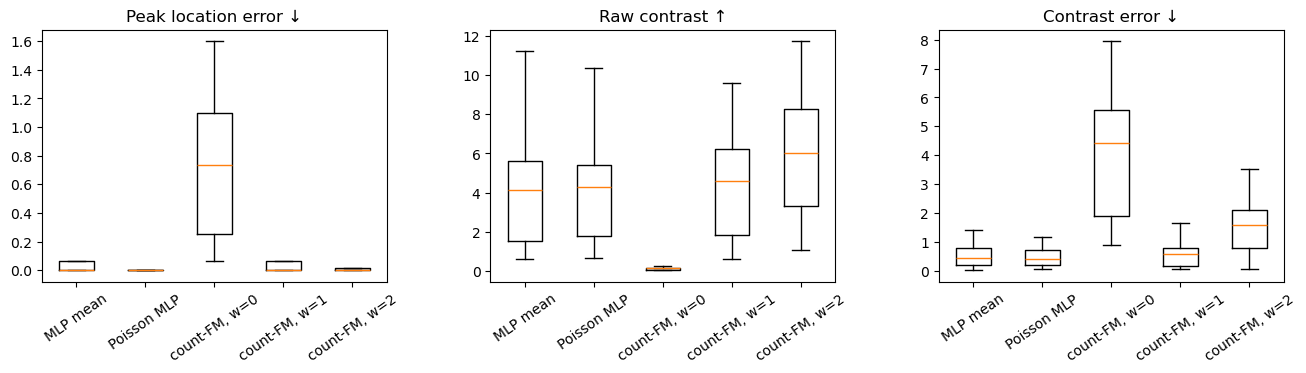

peak_loc_err           contrast_raw           contrast_err  \
                      mean       std         mean       std         mean   
Model                                                                      
MLP mean          0.126667  0.354685     4.197675  2.859264     0.585580   
Poisson MLP       0.076667  0.296786     4.183902  2.765073     0.513498   
count-FM, w=0     0.720000  0.512579     0.135395  0.065618     4.311908   
count-FM, w=1     0.120000  0.342403     4.551881  3.242496     0.613102   
count-FM, w=2     0.076667  0.190137     6.254644  4.008689     1.836356   

                         
                    std  
Model                    
MLP mean       0.513135  
Poisson MLP    0.411100  
count-FM, w=0  2.716288  
count-FM, w=1  0.498700  
count-FM, w=2  1.541234

hc3_paper/figures/hc3_sharpness_summary_outer0_eval0.pdf
hc3_paper/tables/hc3_sharpness_per_neuron_outer0_eval0.csv
hc3_paper/tables/hc3_sharpness_summary_outer0_eval0.csv


In [26]:
# Output results... Cell 6
# Figure 2: sharpness summary across active neurons, saved as PDF

def per_neuron_tuning_metrics(mean_mat, true_mean_mat, centers_vec, active_ids):
    rows = []
    for j in active_ids:
        m = mean_mat[:, j]
        t = true_mean_mat[:, j]
        if not (np.isfinite(m).all() and np.isfinite(t).all()):
            continue

        pm = centers_vec[np.argmax(m)]
        pt = centers_vec[np.argmax(t)]

        cm = (np.max(m) - np.median(m)) / (np.mean(m) + 1e-8)
        ct = (np.max(t) - np.median(t)) / (np.mean(t) + 1e-8)

        rows.append({
            "unit": int(j),
            "peak_loc_err": float(abs(pm - pt)),
            "contrast_raw": float(cm),
            "contrast_err": float(abs(cm - ct)),
        })
    return pd.DataFrame(rows)

sharp_rows = []
for name in MODEL_ORDER:
    _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)
    df_j = per_neuron_tuning_metrics(
        st["mean"],
        true_stats_rep["mean"],
        centers_rep,
        active_ids_rep,
    )
    df_j["Model"] = name
    sharp_rows.append(df_j)

sharp_long_df = pd.concat(sharp_rows, ignore_index=True)
sharp_long_df["Model"] = pd.Categorical(sharp_long_df["Model"], categories=MODEL_ORDER, ordered=True)
sharp_long_df = sharp_long_df.sort_values(["Model", "unit"]).reset_index(drop=True)

sharp_summary_df = (
    sharp_long_df
    .groupby("Model")[["peak_loc_err", "contrast_raw", "contrast_err"]]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

sharp_long_csv = TAB_DIR / f"hc3_sharpness_per_neuron_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.csv"
sharp_summary_csv = TAB_DIR / f"hc3_sharpness_summary_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.csv"
sharp_long_df.to_csv(sharp_long_csv, index=False)
sharp_summary_df.to_csv(sharp_summary_csv)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

metric_specs = [
    ("peak_loc_err", "Peak location error ↓"),
    ("contrast_raw", "Raw contrast ↑"),
    ("contrast_err", "Contrast error ↓"),
]

for ax, (metric, title) in zip(axes, metric_specs):
    data = [
        sharp_long_df.loc[sharp_long_df["Model"] == name, metric].dropna().to_numpy()
        for name in MODEL_ORDER
    ]
    ax.boxplot(data, labels=MODEL_ORDER, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)

fig.subplots_adjust(left=0.06, right=0.98, top=0.88, bottom=0.28, wspace=0.30)

sharp_pdf = FIG_DIR / f"hc3_sharpness_summary_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
fig.savefig(sharp_pdf, bbox_inches="tight")
plt.show()

display(sharp_summary_df)

print(sharp_pdf)
print(sharp_long_csv)
print(sharp_summary_csv)

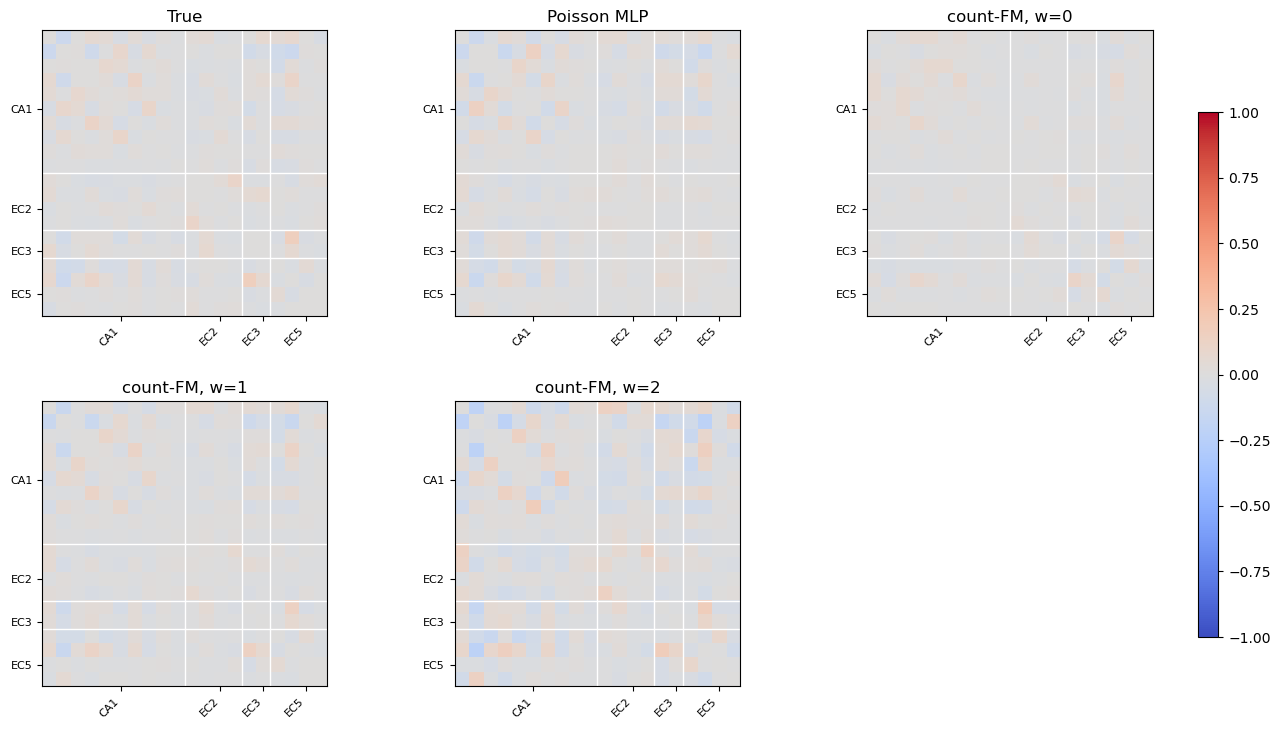

,Model,ResidualCorrNorm,ResidualCorr_Frob_to_true
0,True,0.736330,0.000000
1,Poisson MLP,0.747295,0.415207
2,"count-FM, w=0",0.453557,0.495621
3,"count-FM, w=1",0.728552,0.308801
4,"count-FM, w=2",1.209672,0.697775


hc3_paper/figures/hc3_dependence_outer0_eval0.pdf
hc3_paper/tables/hc3_active_units_dependence_outer0_eval0.csv
hc3_paper/tables/hc3_dependence_numeric_outer0_eval0.csv
dependence neurons: 20


In [27]:
# Output results... Cell 7
# Figure 3: dependence structure, using exactly the same neurons/order as Cell 5

ordered_ids_rep = np.asarray(top_units_rep, dtype=int)
dep_group_info_rep = list(group_info_rep)

dep_df_rep = chosen_df_rep.copy()
if "unit_id" not in dep_df_rep.columns:
    dep_df_rep["unit_id"] = dep_df_rep["unit"].astype(int)

dep_units_csv = TAB_DIR / f"hc3_active_units_dependence_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.csv"
dep_df_rep.to_csv(dep_units_csv, index=False)

true_rows = stack_binned_residuals_mean(
    split_rep["X_test"],
    true_stats_rep["mean"],
    split_rep["cov_test"],
    ordered_ids_rep,
    n_bins=COV_N_BINS,
    min_count=COV_MIN_COUNT,
)

corr_panels = {}
corr_panels["True"] = corr_from_rows_fixed(true_rows)

for name in ["Poisson MLP", "count-FM, w=0", "count-FM, w=1", "count-FM, w=2"]:
    _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)

    rows = stack_binned_residuals_draws(
        pred_draws_rep[name],
        st["mean"],
        split_rep["cov_test"],
        ordered_ids_rep,
        n_bins=COV_N_BINS,
        min_count=COV_MIN_COUNT,
    )

    corr_panels[name] = corr_from_rows_fixed(rows)

dep_num_rows = []
C_true = corr_panels["True"]

dep_num_rows.append({
    "Model": "True",
    "ResidualCorrNorm": float(np.linalg.norm(C_true, ord="fro")),
    "ResidualCorr_Frob_to_true": 0.0,
})

for name in ["Poisson MLP", "count-FM, w=0", "count-FM, w=1", "count-FM, w=2"]:
    C = corr_panels[name]

    dep_num_rows.append({
        "Model": name,
        "ResidualCorrNorm": float(np.linalg.norm(C, ord="fro")),
        "ResidualCorr_Frob_to_true": float(np.linalg.norm(C - C_true, ord="fro")),
    })

dep_num_df = pd.DataFrame(dep_num_rows)

dep_num_csv = TAB_DIR / f"hc3_dependence_numeric_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.csv"
dep_num_df.to_csv(dep_num_csv, index=False)

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.2))
axes = axes.ravel()

bounds = []
centers_x = []
cursor = 0

for region, n_region in dep_group_info_rep:
    centers_x.append((cursor + 0.5 * n_region, region))
    cursor += n_region
    bounds.append(cursor)

bounds = bounds[:-1]

panel_order = ["True", "Poisson MLP", "count-FM, w=0", "count-FM, w=1", "count-FM, w=2"]
im = None

for ax, name in zip(axes[:5], panel_order):
    C = corr_panels[name]

    im = ax.imshow(C, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(name)

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right", fontsize=8)

    ax.set_yticks([c for c, _ in centers_x])
    ax.set_yticklabels([lab for _, lab in centers_x], fontsize=8)

    for b in bounds:
        ax.axvline(b - 0.5, color="white", linewidth=1.0)
        ax.axhline(b - 0.5, color="white", linewidth=1.0)

axes[5].axis("off")

fig.subplots_adjust(
    left=0.07,
    right=0.92,
    top=0.92,
    bottom=0.12,
    wspace=0.28,
    hspace=0.30,
)

cax = fig.add_axes([0.94, 0.18, 0.015, 0.64])
fig.colorbar(im, cax=cax)

dep_pdf = FIG_DIR / f"hc3_dependence_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
fig.savefig(dep_pdf, bbox_inches="tight")
plt.show()

display(dep_num_df)

print(dep_pdf)
print(dep_units_csv)
print(dep_num_csv)
print("dependence neurons:", len(ordered_ids_rep))

In [28]:
# # Output results... Extra shape metrics across seeds
# # This one is CORRECT: inner average within each outer seed, then mean ± std across outer seeds

# EXTRA_SHAPE_METRICS = [
#     "cosine_raw",
#     "cosine_centered",
#     "top3_overlap",
#     "peak_mass_k1_raw",
#     "peak_mass_k1_err",
#     "halfmax_width_raw",
#     "halfmax_width_err",
#     "entropy_raw",
#     "entropy_err",
# ]

# def safe_cosine(a, b, eps=1e-8):
#     na = np.linalg.norm(a)
#     nb = np.linalg.norm(b)
#     if na < eps or nb < eps:
#         return np.nan
#     return float(np.dot(a, b) / (na * nb))

# def normalize_prob(v, eps=1e-12):
#     s = float(np.sum(v))
#     if s <= eps:
#         return None
#     return v / s

# def normalized_entropy(v, eps=1e-12):
#     p = normalize_prob(v, eps=eps)
#     if p is None:
#         return np.nan
#     B = len(p)
#     H = -np.sum(p * np.log(p + eps))
#     return float(H / np.log(B))

# def halfmax_width(v):
#     lo = np.min(v)
#     hi = np.max(v)
#     thr = lo + 0.5 * (hi - lo)
#     return float(np.sum(v >= thr))

# def topk_overlap(v1, v2, k=3):
#     idx1 = set(np.argsort(v1)[-k:])
#     idx2 = set(np.argsort(v2)[-k:])
#     return float(len(idx1 & idx2) / k)

# def peak_mass_near_true(v_pred, v_true, k=1, eps=1e-12):
#     p = int(np.argmax(v_true))
#     lo = max(0, p - k)
#     hi = min(len(v_pred), p + k + 1)
#     denom = float(np.sum(v_pred))
#     if denom <= eps:
#         return np.nan
#     return float(np.sum(v_pred[lo:hi]) / denom)

# def per_neuron_extra_shape_metrics(mean_mat, true_mean_mat, centers_vec, active_ids):
#     rows = []
#     for j in active_ids:
#         m = mean_mat[:, j]
#         t = true_mean_mat[:, j]

#         if not (np.isfinite(m).all() and np.isfinite(t).all()):
#             continue
#         if (np.max(t) - np.min(t)) < 1e-8:
#             continue

#         pm_true = peak_mass_near_true(t, t, k=1)

#         rows.append({
#             "unit": int(j),
#             "cosine_raw": safe_cosine(m, t),
#             "cosine_centered": safe_cosine(m - m.mean(), t - t.mean()),
#             "top3_overlap": topk_overlap(m, t, k=3),
#             "peak_mass_k1_raw": peak_mass_near_true(m, t, k=1),
#             "peak_mass_k1_err": abs(peak_mass_near_true(m, t, k=1) - pm_true),
#             "halfmax_width_raw": halfmax_width(m),
#             "halfmax_width_err": abs(halfmax_width(m) - halfmax_width(t)),
#             "entropy_raw": normalized_entropy(m),
#             "entropy_err": abs(normalized_entropy(m) - normalized_entropy(t)),
#         })
#     return pd.DataFrame(rows)

# extra_outer_rows = []

# for outer_seed in OUTER_SEEDS:
#     split_outer = build_outer_split(outer_seed)
#     mlp_outer, pois_outer, fm_outer, x0_outer, _, _ = load_or_train_outer_seed(
#         outer_seed,
#         split_outer,
#         train_if_missing=TRAIN_IF_MISSING,
#     )

#     active_ids_outer = np.where(split_outer["X_train"].mean(axis=0) > ACTIVE_THRESH)[0]
#     if len(active_ids_outer) < 2:
#         active_ids_outer = np.arange(split_outer["X_train"].shape[1])

#     inner_rows = []

#     for eval_seed in INNER_EVAL_SEEDS:
#         pred_mean_eval, pred_draws_eval = predict_all_for_split(
#             mlp_mean_local=mlp_outer,
#             pois_mlp_local=pois_outer,
#             fm_net_local=fm_outer,
#             split=split_outer,
#             x0_rate_local=x0_outer,
#             eval_seed=10000 * (outer_seed + 1) + eval_seed,
#             n_rep_mean=N_REP_MEAN_TABLE,
#             keep_draws=KEEP_DRAWS_TABLE,
#             rep_batch=REP_BATCH_TABLE,
#         )

#         centers_eval, counts_eval, true_stats_eval = binned_stats(
#             split_outer["X_test"],
#             split_outer["cov_test"],
#             n_bins=N_BINS,
#         )

#         for name in MODEL_ORDER:
#             _, _, st = binned_stats(pred_mean_eval[name], split_outer["cov_test"], n_bins=N_BINS)
#             df_j = per_neuron_extra_shape_metrics(
#                 st["mean"],
#                 true_stats_eval["mean"],
#                 centers_eval,
#                 active_ids_outer,
#             )

#             row = {"outer_seed": outer_seed, "eval_seed": eval_seed, "Model": name}
#             for metric in EXTRA_SHAPE_METRICS:
#                 row[metric] = float(df_j[metric].mean()) if len(df_j) > 0 else np.nan
#             inner_rows.append(row)

#     inner_df = pd.DataFrame(inner_rows)
#     inner_avg_df = inner_df.groupby("Model")[EXTRA_SHAPE_METRICS].mean().reset_index()
#     inner_avg_df["outer_seed"] = outer_seed
#     extra_outer_rows.append(inner_avg_df)

# extra_outer_df = pd.concat(extra_outer_rows, ignore_index=True)
# extra_outer_df["Model"] = pd.Categorical(extra_outer_df["Model"], categories=MODEL_ORDER, ordered=True)
# extra_outer_df = extra_outer_df.sort_values(["Model", "outer_seed"]).reset_index(drop=True)

# extra_summary_num = (
#     extra_outer_df
#     .groupby("Model")[EXTRA_SHAPE_METRICS]
#     .agg(["mean", "std"])
#     .reindex(MODEL_ORDER)
# )

# extra_summary_pretty = flatten_summary_table(extra_summary_num, EXTRA_SHAPE_METRICS)

# extra_outer_csv = TAB_DIR / "hc3_extra_shape_metrics_outer_seed_avg.csv"
# extra_num_csv = TAB_DIR / "hc3_extra_shape_metrics_mean_std_numeric.csv"
# extra_pretty_csv = TAB_DIR / "hc3_extra_shape_metrics_mean_std_pretty.csv"
# extra_tex = TAB_DIR / "hc3_extra_shape_metrics_mean_std.tex"

# extra_outer_df.to_csv(extra_outer_csv, index=False)
# extra_summary_num.to_csv(extra_num_csv)
# extra_summary_pretty.to_csv(extra_pretty_csv, index=False)
# with open(extra_tex, "w") as f:
#     f.write(extra_summary_pretty.to_latex(index=False, escape=False))

# display(extra_outer_df)
# display(extra_summary_num)
# display(extra_summary_pretty)

# print(extra_outer_csv)
# print(extra_num_csv)
# print(extra_pretty_csv)
# print(extra_tex)

# Supplementary plot

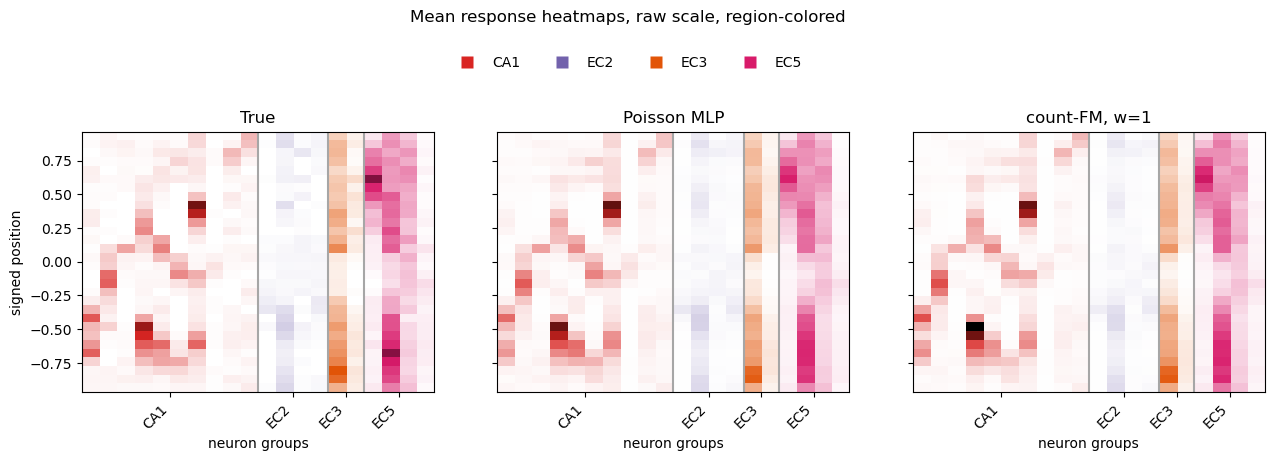

,unit,region,n_spikes,plot_peak,plot_baseline,plot_dynamic,plot_contrast,plot_spatial_info,train_spatial_info,stability,select_score
0,42,CA1,1348,0.424000,0.018959,0.405041,0.955286,1.352258,1.322206,0.936367,7.22
1,28,CA1,1419,0.402778,0.018695,0.384083,0.953585,1.366432,1.277561,0.481936,6.63
2,59,CA1,483,0.229730,0.011398,0.218331,0.950384,1.478653,1.209517,0.921405,6.52
3,60,CA1,2630,0.617021,0.048914,0.568108,0.920726,0.979213,0.982193,0.967857,6.45
4,57,CA1,1616,0.376404,0.027836,0.348569,0.926048,0.986595,1.112922,0.670100,6.00
5,61,CA1,1310,0.295918,0.017573,0.278346,0.940616,1.275789,1.152160,0.646108,5.97
6,49,CA1,2818,0.661017,0.068773,0.592244,0.895959,0.762486,0.652000,0.877658,5.91
7,52,CA1,229,0.070461,0.003208,0.067252,0.954465,1.616447,2.140945,0.937964,5.75
8,35,CA1,683,0.175824,0.020557,0.155268,0.883084,0.820806,0.582078,0.870463,4.71
9,54,CA1,840,0.181818,0.022372,0.159446,0.876952,0.800615,0.767956,0.772176,4.68


hc3_paper/figures/hc3_mean_response_region_colored_outer0_eval0.pdf
selected neurons: 20
Shared raw vmax_heat: 0.7852482269503547


In [29]:
# New cell: region-colored heatmaps using exactly the same neurons as Cell 5
# No neuron-wise normalization

panel_order_heat = ["True", "Poisson MLP", "count-FM, w=1"]

top_units_heat = np.asarray(top_units_rep, dtype=int)
group_info_heat = list(group_info_rep)
chosen_df_heat = chosen_df_rep.copy()

heat_stats = {}
for name in panel_order_heat:
    if name in show_stats_rep:
        heat_stats[name] = show_stats_rep[name]
    else:
        _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)
        heat_stats[name] = st["mean"]

vmax_heat = np.nanmax(
    np.stack([heat_stats[name][:, top_units_heat] for name in panel_order_heat], axis=0)
)
vmax_heat = vmax_heat if np.isfinite(vmax_heat) and vmax_heat > 0 else 1.0

region_to_cmap = {
    "CA1": "Reds",
    "CA3": "Blues",
    "DG": "Greens",
    "EC2": "Purples",
    "EC3": "Oranges",
    "EC4": "YlOrBr",
    "EC5": "PuRd",
}

unit_rgb = np.zeros((len(top_units_heat), 3), dtype=float)
region_legend_colors = {}

cursor = 0

for region, n_region in group_info_heat:
    idx = np.arange(cursor, cursor + n_region)

    cmap = plt.get_cmap(region_to_cmap.get(region, "Greys"))
    region_color = np.array(cmap(0.70)[:3])

    unit_rgb[idx] = region_color
    region_legend_colors[region] = region_color

    cursor += n_region

def region_colored_raw_heatmap(M, unit_rgb, vmax, mid=0.70):
    Z = np.nan_to_num(M / vmax, nan=0.0, posinf=1.0, neginf=0.0)
    Z = np.clip(Z, 0, 1)

    rgb = np.ones((Z.shape[0], Z.shape[1], 3), dtype=float)

    for j in range(Z.shape[1]):
        c = unit_rgb[j]
        z = Z[:, j]

        low = z <= mid
        high = ~low

        alpha = z[low] / mid
        rgb[low, j, :] = (1.0 - alpha[:, None]) * 1.0 + alpha[:, None] * c[None, :]

        beta = (z[high] - mid) / (1.0 - mid)
        rgb[high, j, :] = (1.0 - beta[:, None]) * c[None, :]

    return rgb

bounds = []
centers_x = []
cursor = 0

for region, n_region in group_info_heat:
    centers_x.append((cursor + 0.5 * n_region, region))
    cursor += n_region
    bounds.append(cursor)

bounds = bounds[:-1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)

for ax, name in zip(axes, panel_order_heat):
    M = heat_stats[name][:, top_units_heat]
    rgb = region_colored_raw_heatmap(M, unit_rgb, vmax_heat)

    ax.imshow(
        rgb,
        aspect="auto",
        origin="lower",
        extent=[0, len(top_units_heat), centers_rep[0], centers_rep[-1]],
    )

    ax.set_title(name)
    ax.set_xlabel("neuron groups")

    for b in bounds:
        ax.axvline(b, color="0.65", linewidth=1.5)

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right")

axes[0].set_ylabel("signed position")

handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markersize=8,
        markerfacecolor=region_legend_colors[r],
        markeredgecolor="none",
        label=r,
    )
    for r, _ in group_info_heat
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=min(len(handles), 7),
    frameon=False,
)

fig.suptitle(
    "Mean response heatmaps, raw scale, region-colored",
    y=1.13,
)

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.84,
    bottom=0.22,
    wspace=0.18,
)

colored_pdf = FIG_DIR / f"hc3_mean_response_region_colored_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
fig.savefig(colored_pdf, bbox_inches="tight")
plt.show()

display_cols = [
    "unit",
    "region",
    "n_spikes",
    "plot_peak",
    "plot_baseline",
    "plot_dynamic",
    "plot_contrast",
    "plot_spatial_info",
    "train_spatial_info",
    "stability",
    "select_score",
]

display(chosen_df_heat[[c for c in display_cols if c in chosen_df_heat.columns]])

print(colored_pdf)
print("selected neurons:", len(top_units_heat))
print("Shared raw vmax_heat:", vmax_heat)

In [53]:
# # Combined 2-row figure:
# # Row 1: region-colored mean heatmaps, no neuron-wise normalization
# # Row 2: residual correlation matrices, same neurons/order, clearer off-diagonal contrast

# # from matplotlib.colors import TwoSlopeNorm
# from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
# from matplotlib.cm import ScalarMappable

# panel_order_combo = ["True", "Poisson MLP", "count-FM, w=1"]

# top_units_combo = np.asarray(top_units_rep, dtype=int)
# group_info_combo = list(group_info_rep)

# # -----------------------------
# # Shared group boundaries/labels
# # -----------------------------
# bounds = []
# centers_x = []
# cursor = 0

# for region, n_region in group_info_combo:
#     centers_x.append((cursor + 0.5 * n_region, region))
#     cursor += n_region
#     bounds.append(cursor)

# bounds = bounds[:-1]

# # -----------------------------
# # Row 1: region-colored heatmaps
# # -----------------------------
# heat_stats_combo = {}

# for name in panel_order_combo:
#     if name in show_stats_rep:
#         heat_stats_combo[name] = show_stats_rep[name]
#     else:
#         _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)
#         heat_stats_combo[name] = st["mean"]

# centers_combo, _, _ = binned_stats(
#     split_rep["X_test"],
#     split_rep["cov_test"],
#     n_bins=N_BINS,
# )

# vmax_heat_combo = np.nanmax(
#     np.stack([heat_stats_combo[name][:, top_units_combo] for name in panel_order_combo], axis=0)
# )
# vmax_heat_combo = vmax_heat_combo if np.isfinite(vmax_heat_combo) and vmax_heat_combo > 0 else 1.0

# region_to_cmap = {
#     "CA1": "Reds",
#     "CA3": "Blues",
#     "DG": "Greens",
#     "EC2": "Purples",
#     "EC3": "Oranges",
#     "EC4": "YlOrBr",
#     "EC5": "PuRd",
# }

# unit_rgb = np.zeros((len(top_units_combo), 3), dtype=float)
# region_legend_colors = {}

# cursor = 0
# for region, n_region in group_info_combo:
#     idx = np.arange(cursor, cursor + n_region)

#     cmap = plt.get_cmap(region_to_cmap.get(region, "Greys"))
#     region_color = np.array(cmap(0.70)[:3])

#     unit_rgb[idx] = region_color
#     region_legend_colors[region] = region_color

#     cursor += n_region

# def region_colored_raw_heatmap(M, unit_rgb, vmax, mid=0.70):
#     Z = np.nan_to_num(M / vmax, nan=0.0, posinf=1.0, neginf=0.0)
#     Z = np.clip(Z, 0, 1)

#     rgb = np.ones((Z.shape[0], Z.shape[1], 3), dtype=float)

#     for j in range(Z.shape[1]):
#         c = unit_rgb[j]
#         z = Z[:, j]

#         low = z <= mid
#         high = ~low

#         alpha = z[low] / mid
#         rgb[low, j, :] = (1.0 - alpha[:, None]) * 1.0 + alpha[:, None] * c[None, :]

#         beta = (z[high] - mid) / (1.0 - mid)
#         rgb[high, j, :] = (1.0 - beta[:, None]) * c[None, :]

#     return rgb

# # -----------------------------
# # Row 2: residual correlations
# # -----------------------------
# true_rows_combo = stack_binned_residuals_mean(
#     split_rep["X_test"],
#     true_stats_rep["mean"],
#     split_rep["cov_test"],
#     top_units_combo,
#     n_bins=COV_N_BINS,
#     min_count=COV_MIN_COUNT,
# )

# corr_panels_combo = {"True": corr_from_rows_fixed(true_rows_combo)}

# for name in ["Poisson MLP", "count-FM, w=1"]:
#     _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)

#     rows = stack_binned_residuals_draws(
#         pred_draws_rep[name],
#         st["mean"],
#         split_rep["cov_test"],
#         top_units_combo,
#         n_bins=COV_N_BINS,
#         min_count=COV_MIN_COUNT,
#     )

#     corr_panels_combo[name] = corr_from_rows_fixed(rows)

# # make covariance/correlation patterns easier to see:
# # ignore diagonal and use robust off-diagonal scale

# # corr_vmax = 0.5
# # corr_norm = TwoSlopeNorm(vmin=-0.5, vcenter=0.0, vmax=0.5)

# # # force zero correlation to be pure white
# # corr_cmap = LinearSegmentedColormap.from_list(
# #     "blue_white_red",
# #     [
# #         (0.0, "#3b4cc0"),   # negative
# #         (0.5, "#ffffff"),   # zero
# #         (1.0, "#b40426"),   # positive
# #     ],
# # )

# def corr_for_display(C):
#     C = np.array(C, dtype=float, copy=True)
#     np.fill_diagonal(C, 0.0)
#     return C

# corr_vals = []

# for name in panel_order_combo:
#     C_disp = corr_for_display(corr_panels_combo[name])
#     vals = C_disp[np.isfinite(C_disp)]
#     corr_vals.append(vals)

# corr_vals = np.concatenate(corr_vals)

# corr_data_min = float(np.nanmin(corr_vals))
# corr_data_max = float(np.nanmax(corr_vals))

# corr_pad = 0.05 * (corr_data_max - corr_data_min)
# if not np.isfinite(corr_pad) or corr_pad <= 0:
#     corr_pad = 0.05

# corr_vmin = corr_data_min - corr_pad
# corr_vmax = corr_data_max + corr_pad

# # make sure zero is inside the scale
# corr_vmin = min(corr_vmin, -1e-6)
# corr_vmax = max(corr_vmax, 1e-6)

# corr_norm = TwoSlopeNorm(
#     vmin=corr_vmin,
#     vcenter=0.0,
#     vmax=corr_vmax,
# )

# # force zero correlation to be pure white
# corr_cmap = LinearSegmentedColormap.from_list(
#     "blue_white_red",
#     [
#         (0.0, "#3b4cc0"),   # negative
#         (0.5, "#ffffff"),   # zero
#         (1.0, "#b40426"),   # positive
#     ],
# )


# # def corr_for_display(C):
# #     return C

# # -----------------------------
# # Plot combined figure
# # -----------------------------
# fig, axes = plt.subplots(
#     2,
#     3,
#     figsize=(14, 8.4),
#     gridspec_kw={"height_ratios": [1.0, 1.05]},
# )

# # Row 1
# for ax, name in zip(axes[0], panel_order_combo):
#     M = heat_stats_combo[name][:, top_units_combo]
#     rgb = region_colored_raw_heatmap(M, unit_rgb, vmax_heat_combo)

#     ax.imshow(
#         rgb,
#         aspect="auto",
#         origin="lower",
#         extent=[0, len(top_units_combo), centers_combo[0], centers_combo[-1]],
#     )

#     ax.set_title(name)
#     ax.set_xlabel("neuron groups")

#     for b in bounds:
#         ax.axvline(b, color="0.65", linewidth=1.5)

#     ax.set_xticks([c for c, _ in centers_x])
#     ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right")

# axes[0, 0].set_ylabel("signed position")

# # Row 2
# im_corr = None

# for ax, name in zip(axes[1], panel_order_combo):
#     C = corr_for_display(corr_panels_combo[name])

#     im_corr = ax.imshow(
#         C,
#         cmap=corr_cmap,
#         norm=corr_norm,
#         origin="upper",
#         aspect="auto",
#     )

    

#     # im_corr = ax.imshow(
#     #     C,
#     #     cmap=corr_cmap,
#     #     norm=corr_norm,
#     #     origin="upper",
#     # )

#     ax.set_title(name)
#     ax.set_xlabel("neuron groups")

#     ax.set_xticks([c for c, _ in centers_x])
#     ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right", fontsize=8)

#     ax.set_yticks([c for c, _ in centers_x])
#     ax.set_yticklabels([lab for _, lab in centers_x], fontsize=8)

#     for b in bounds:
#         ax.axvline(b - 0.5, color="0.25", linewidth=0.8)
#         ax.axhline(b - 0.5, color="0.25", linewidth=0.8)

# axes[1, 0].set_ylabel("neuron groups")

# # Region legend
# handles = [
#     plt.Line2D(
#         [0], [0],
#         marker="s",
#         linestyle="",
#         markersize=8,
#         markerfacecolor=region_legend_colors[r],
#         markeredgecolor="none",
#         label=r,
#     )
#     for r, _ in group_info_combo
# ]

# fig.legend(
#     handles=handles,
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.02),
#     ncol=min(len(handles), 7),
#     frameon=False,
# )

# # Correlation colorbar
# # Layout first
# fig.text(
#     0.5,
#     0.965,
#     "Mean response heatmaps and residual correlation structure",
#     ha="center",
#     va="center",
#     fontsize=13,
# )

# fig.subplots_adjust(
#     left=0.07,
#     right=0.90,
#     top=0.91,
#     bottom=0.10,
#     wspace=0.25,
#     hspace=0.42,
# )

# # Correlation colorbar
# # compute colorbar position after subplots_adjust, otherwise it will be misaligned
# fig.canvas.draw()

# sm = ScalarMappable(norm=corr_norm, cmap=corr_cmap)
# sm.set_array([])

# row2_pos = [ax.get_position() for ax in axes[1, :]]

# x0 = max(p.x1 for p in row2_pos) + 0.015
# y0 = min(p.y0 for p in row2_pos)
# y1 = max(p.y1 for p in row2_pos)

# cax = fig.add_axes([x0, y0, 0.015, y1 - y0])
# cbar = fig.colorbar(sm, cax=cax)
# cbar.set_label("residual correlation")


# combo_pdf = FIG_DIR / f"hc3_mean_and_dependence_combined_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
# fig.savefig(combo_pdf, bbox_inches="tight")
# plt.show()

# print(combo_pdf)
# print("Shared heatmap vmax =", vmax_heat_combo)
# # print("Residual correlation color scale = +/-", corr_vmax)
# print("Residual correlation color scale =", (corr_vmin, corr_vmax))

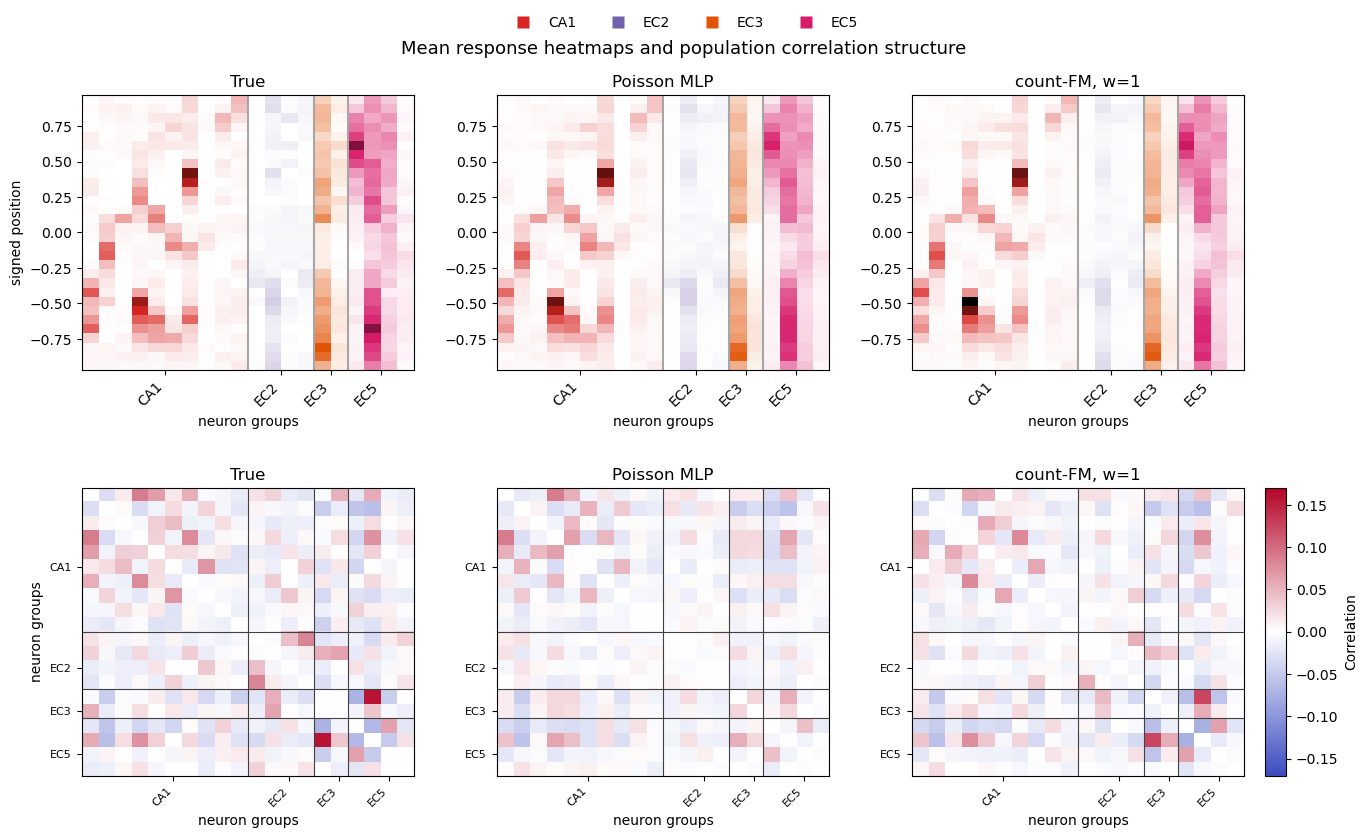

hc3_paper/figures/hc3_mean_and_population_correlation_combined_outer0_eval0.pdf
Shared heatmap vmax = 0.7852482269503547
Population correlation color scale = (-0.17032929413649878, 0.17032929413649878)


In [51]:
# Combined 2-row figure:
# Row 1: region-colored mean heatmaps, no neuron-wise normalization
# Row 2: residual correlation matrices, same neurons/order, clearer off-diagonal contrast

# from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

panel_order_combo = ["True", "Poisson MLP", "count-FM, w=1"]

top_units_combo = np.asarray(top_units_rep, dtype=int)
group_info_combo = list(group_info_rep)

# -----------------------------
# Shared group boundaries/labels
# -----------------------------
bounds = []
centers_x = []
cursor = 0

for region, n_region in group_info_combo:
    centers_x.append((cursor + 0.5 * n_region, region))
    cursor += n_region
    bounds.append(cursor)

bounds = bounds[:-1]

# -----------------------------
# Row 1: region-colored heatmaps
# -----------------------------
heat_stats_combo = {}

for name in panel_order_combo:
    if name in show_stats_rep:
        heat_stats_combo[name] = show_stats_rep[name]
    else:
        _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)
        heat_stats_combo[name] = st["mean"]

centers_combo, _, _ = binned_stats(
    split_rep["X_test"],
    split_rep["cov_test"],
    n_bins=N_BINS,
)

vmax_heat_combo = np.nanmax(
    np.stack([heat_stats_combo[name][:, top_units_combo] for name in panel_order_combo], axis=0)
)
vmax_heat_combo = vmax_heat_combo if np.isfinite(vmax_heat_combo) and vmax_heat_combo > 0 else 1.0

region_to_cmap = {
    "CA1": "Reds",
    "CA3": "Blues",
    "DG": "Greens",
    "EC2": "Purples",
    "EC3": "Oranges",
    "EC4": "YlOrBr",
    "EC5": "PuRd",
}

unit_rgb = np.zeros((len(top_units_combo), 3), dtype=float)
region_legend_colors = {}

cursor = 0
for region, n_region in group_info_combo:
    idx = np.arange(cursor, cursor + n_region)

    cmap = plt.get_cmap(region_to_cmap.get(region, "Greys"))
    region_color = np.array(cmap(0.70)[:3])

    unit_rgb[idx] = region_color
    region_legend_colors[region] = region_color

    cursor += n_region

def region_colored_raw_heatmap(M, unit_rgb, vmax, mid=0.70):
    Z = np.nan_to_num(M / vmax, nan=0.0, posinf=1.0, neginf=0.0)
    Z = np.clip(Z, 0, 1)

    rgb = np.ones((Z.shape[0], Z.shape[1], 3), dtype=float)

    for j in range(Z.shape[1]):
        c = unit_rgb[j]
        z = Z[:, j]

        low = z <= mid
        high = ~low

        alpha = z[low] / mid
        rgb[low, j, :] = (1.0 - alpha[:, None]) * 1.0 + alpha[:, None] * c[None, :]

        beta = (z[high] - mid) / (1.0 - mid)
        rgb[high, j, :] = (1.0 - beta[:, None]) * c[None, :]

    return rgb

# -----------------------------
# Row 2: ordinary population correlations
# -----------------------------
def corr_from_X_plain(X, unit_ids=None, eps=1e-8):
    X = np.asarray(X, dtype=float)

    if unit_ids is not None:
        Z = X[:, unit_ids]
    else:
        Z = X

    Z = Z - Z.mean(axis=0, keepdims=True)

    sd = Z.std(axis=0, ddof=0)
    keep = sd > eps

    Zn = np.zeros_like(Z)
    Zn[:, keep] = Z[:, keep] / sd[keep][None, :]

    C = (Zn.T @ Zn) / max(Z.shape[0], 1)
    np.fill_diagonal(C, 0.0)

    return C

def flatten_draws_for_corr(draws, unit_ids):
    G = np.asarray(draws[:, :, unit_ids], dtype=float)
    return G.reshape(-1, len(unit_ids))

corr_panels_combo = {}

corr_panels_combo["True"] = corr_from_X_plain(
    split_rep["X_test"],
    unit_ids=top_units_combo,
)

for name in ["Poisson MLP", "count-FM, w=1"]:
    Xg = flatten_draws_for_corr(pred_draws_rep[name], top_units_combo)
    corr_panels_combo[name] = corr_from_X_plain(Xg, unit_ids=None)

# make covariance/correlation patterns easier to see:
# ignore diagonal and use robust off-diagonal scale

# corr_vmax = 0.5
# corr_norm = TwoSlopeNorm(vmin=-0.5, vcenter=0.0, vmax=0.5)

# # force zero correlation to be pure white
# corr_cmap = LinearSegmentedColormap.from_list(
#     "blue_white_red",
#     [
#         (0.0, "#3b4cc0"),   # negative
#         (0.5, "#ffffff"),   # zero
#         (1.0, "#b40426"),   # positive
#     ],
# )

def corr_for_display(C):
    C = np.array(C, dtype=float, copy=True)
    np.fill_diagonal(C, 0.0)
    return C

corr_vals = []

for name in panel_order_combo:
    C_disp = corr_for_display(corr_panels_combo[name])
    offdiag = ~np.eye(C_disp.shape[0], dtype=bool)
    vals = C_disp[offdiag]
    vals = vals[np.isfinite(vals)]
    corr_vals.append(vals)

corr_vals = np.concatenate(corr_vals)

corr_data_min = float(np.nanmin(corr_vals))
corr_data_max = float(np.nanmax(corr_vals))

corr_pad = 0.05 * (corr_data_max - corr_data_min)
if not np.isfinite(corr_pad) or corr_pad <= 0:
    corr_pad = 0.05

corr_absmax = max(
    abs(corr_data_min - corr_pad),
    abs(corr_data_max + corr_pad),
    1e-6,
)

corr_vmin = -corr_absmax
corr_vmax = corr_absmax

corr_norm = TwoSlopeNorm(
    vmin=corr_vmin,
    vcenter=0.0,
    vmax=corr_vmax,
)

# force zero correlation to be pure white
corr_cmap = LinearSegmentedColormap.from_list(
    "blue_white_red",
    [
        (0.0, "#3b4cc0"),   # negative
        (0.5, "#ffffff"),   # zero
        (1.0, "#b40426"),   # positive
    ],
)


# def corr_for_display(C):
#     return C

# -----------------------------
# Plot combined figure
# -----------------------------
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8.4),
    gridspec_kw={"height_ratios": [1.0, 1.05]},
)

# Row 1
for ax, name in zip(axes[0], panel_order_combo):
    M = heat_stats_combo[name][:, top_units_combo]
    rgb = region_colored_raw_heatmap(M, unit_rgb, vmax_heat_combo)

    ax.imshow(
        rgb,
        aspect="auto",
        origin="lower",
        extent=[0, len(top_units_combo), centers_combo[0], centers_combo[-1]],
    )

    ax.set_title(name)
    ax.set_xlabel("neuron groups")

    for b in bounds:
        ax.axvline(b, color="0.65", linewidth=1.5)

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right")

axes[0, 0].set_ylabel("signed position")

# Row 2
im_corr = None

for ax, name in zip(axes[1], panel_order_combo):
    C = corr_for_display(corr_panels_combo[name])

    im_corr = ax.imshow(
        C,
        cmap=corr_cmap,
        norm=corr_norm,
        origin="upper",
        aspect="auto",
    )

    

    # im_corr = ax.imshow(
    #     C,
    #     cmap=corr_cmap,
    #     norm=corr_norm,
    #     origin="upper",
    # )

    ax.set_title(name)
    ax.set_xlabel("neuron groups")

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right", fontsize=8)

    ax.set_yticks([c for c, _ in centers_x])
    ax.set_yticklabels([lab for _, lab in centers_x], fontsize=8)

    for b in bounds:
        ax.axvline(b - 0.5, color="0.25", linewidth=0.8)
        ax.axhline(b - 0.5, color="0.25", linewidth=0.8)

axes[1, 0].set_ylabel("neuron groups")

# Region legend
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markersize=8,
        markerfacecolor=region_legend_colors[r],
        markeredgecolor="none",
        label=r,
    )
    for r, _ in group_info_combo
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=min(len(handles), 7),
    frameon=False,
)

# Correlation colorbar
# Layout first
fig.text(
    0.5,
    0.965,
    "Mean response heatmaps and population correlation structure",
    ha="center",
    va="center",
    fontsize=13,
)

fig.subplots_adjust(
    left=0.07,
    right=0.90,
    top=0.91,
    bottom=0.10,
    wspace=0.25,
    hspace=0.42,
)

# Correlation colorbar
# compute colorbar position after subplots_adjust, otherwise it will be misaligned
fig.canvas.draw()

sm = ScalarMappable(norm=corr_norm, cmap=corr_cmap)
sm.set_array([])

row2_pos = [ax.get_position() for ax in axes[1, :]]

x0 = max(p.x1 for p in row2_pos) + 0.015
y0 = min(p.y0 for p in row2_pos)
y1 = max(p.y1 for p in row2_pos)

cax = fig.add_axes([x0, y0, 0.015, y1 - y0])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Correlation")


# combo_pdf = FIG_DIR / f"hc3_mean_and_dependence_combined_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
combo_pdf = FIG_DIR / f"hc3_mean_and_population_correlation_combined_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
fig.savefig(combo_pdf, bbox_inches="tight")
plt.show()

print(combo_pdf)
print("Shared heatmap vmax =", vmax_heat_combo)
# print("Residual correlation color scale = +/-", corr_vmax)
# print("Residual correlation color scale =", (corr_vmin, corr_vmax))
print("Population correlation color scale =", (corr_vmin, corr_vmax))

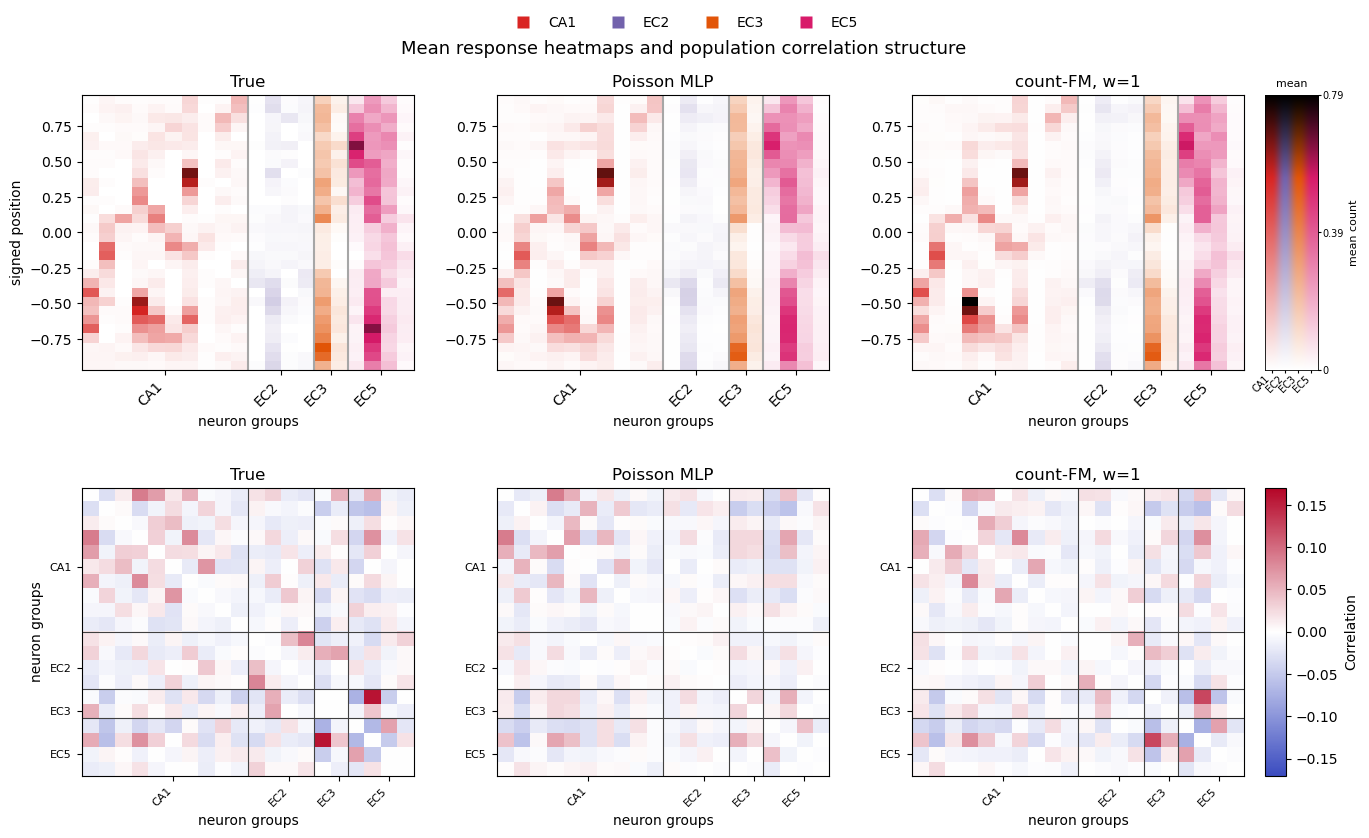

hc3_paper/figures/hc3_mean_and_population_correlation_combined_outer0_eval0.pdf
Shared heatmap vmax = 0.7852482269503547
Population correlation color scale = (-0.17032929413649878, 0.17032929413649878)


In [59]:
# Combined 2-row figure:
# Row 1: region-colored mean heatmaps, no neuron-wise normalization
# Row 2: residual correlation matrices, same neurons/order, clearer off-diagonal contrast

# from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

panel_order_combo = ["True", "Poisson MLP", "count-FM, w=1"]

top_units_combo = np.asarray(top_units_rep, dtype=int)
group_info_combo = list(group_info_rep)

# -----------------------------
# Shared group boundaries/labels
# -----------------------------
bounds = []
centers_x = []
cursor = 0

for region, n_region in group_info_combo:
    centers_x.append((cursor + 0.5 * n_region, region))
    cursor += n_region
    bounds.append(cursor)

bounds = bounds[:-1]

# -----------------------------
# Row 1: region-colored heatmaps
# -----------------------------
heat_stats_combo = {}

for name in panel_order_combo:
    if name in show_stats_rep:
        heat_stats_combo[name] = show_stats_rep[name]
    else:
        _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)
        heat_stats_combo[name] = st["mean"]

centers_combo, _, _ = binned_stats(
    split_rep["X_test"],
    split_rep["cov_test"],
    n_bins=N_BINS,
)

vmax_heat_combo = np.nanmax(
    np.stack([heat_stats_combo[name][:, top_units_combo] for name in panel_order_combo], axis=0)
)
vmax_heat_combo = vmax_heat_combo if np.isfinite(vmax_heat_combo) and vmax_heat_combo > 0 else 1.0

region_to_cmap = {
    "CA1": "Reds",
    "CA3": "Blues",
    "DG": "Greens",
    "EC2": "Purples",
    "EC3": "Oranges",
    "EC4": "YlOrBr",
    "EC5": "PuRd",
}

unit_rgb = np.zeros((len(top_units_combo), 3), dtype=float)
region_legend_colors = {}

cursor = 0
for region, n_region in group_info_combo:
    idx = np.arange(cursor, cursor + n_region)

    cmap = plt.get_cmap(region_to_cmap.get(region, "Greys"))
    region_color = np.array(cmap(0.70)[:3])

    unit_rgb[idx] = region_color
    region_legend_colors[region] = region_color

    cursor += n_region

def region_colored_raw_heatmap(M, unit_rgb, vmax, mid=0.70):
    Z = np.nan_to_num(M / vmax, nan=0.0, posinf=1.0, neginf=0.0)
    Z = np.clip(Z, 0, 1)

    rgb = np.ones((Z.shape[0], Z.shape[1], 3), dtype=float)

    for j in range(Z.shape[1]):
        c = unit_rgb[j]
        z = Z[:, j]

        low = z <= mid
        high = ~low

        alpha = z[low] / mid
        rgb[low, j, :] = (1.0 - alpha[:, None]) * 1.0 + alpha[:, None] * c[None, :]

        beta = (z[high] - mid) / (1.0 - mid)
        rgb[high, j, :] = (1.0 - beta[:, None]) * c[None, :]

    return rgb

# -----------------------------
# Row 2: ordinary population correlations
# -----------------------------
def corr_from_X_plain(X, unit_ids=None, eps=1e-8):
    X = np.asarray(X, dtype=float)

    if unit_ids is not None:
        Z = X[:, unit_ids]
    else:
        Z = X

    Z = Z - Z.mean(axis=0, keepdims=True)

    sd = Z.std(axis=0, ddof=0)
    keep = sd > eps

    Zn = np.zeros_like(Z)
    Zn[:, keep] = Z[:, keep] / sd[keep][None, :]

    C = (Zn.T @ Zn) / max(Z.shape[0], 1)
    np.fill_diagonal(C, 0.0)

    return C

def flatten_draws_for_corr(draws, unit_ids):
    G = np.asarray(draws[:, :, unit_ids], dtype=float)
    return G.reshape(-1, len(unit_ids))

corr_panels_combo = {}

corr_panels_combo["True"] = corr_from_X_plain(
    split_rep["X_test"],
    unit_ids=top_units_combo,
)

for name in ["Poisson MLP", "count-FM, w=1"]:
    Xg = flatten_draws_for_corr(pred_draws_rep[name], top_units_combo)
    corr_panels_combo[name] = corr_from_X_plain(Xg, unit_ids=None)

# make covariance/correlation patterns easier to see:
# ignore diagonal and use robust off-diagonal scale

# corr_vmax = 0.5
# corr_norm = TwoSlopeNorm(vmin=-0.5, vcenter=0.0, vmax=0.5)

# # force zero correlation to be pure white
# corr_cmap = LinearSegmentedColormap.from_list(
#     "blue_white_red",
#     [
#         (0.0, "#3b4cc0"),   # negative
#         (0.5, "#ffffff"),   # zero
#         (1.0, "#b40426"),   # positive
#     ],
# )

def corr_for_display(C):
    C = np.array(C, dtype=float, copy=True)
    np.fill_diagonal(C, 0.0)
    return C

corr_vals = []

for name in panel_order_combo:
    C_disp = corr_for_display(corr_panels_combo[name])
    offdiag = ~np.eye(C_disp.shape[0], dtype=bool)
    vals = C_disp[offdiag]
    vals = vals[np.isfinite(vals)]
    corr_vals.append(vals)

corr_vals = np.concatenate(corr_vals)

corr_data_min = float(np.nanmin(corr_vals))
corr_data_max = float(np.nanmax(corr_vals))

corr_pad = 0.05 * (corr_data_max - corr_data_min)
if not np.isfinite(corr_pad) or corr_pad <= 0:
    corr_pad = 0.05

corr_absmax = max(
    abs(corr_data_min - corr_pad),
    abs(corr_data_max + corr_pad),
    1e-6,
)

corr_vmin = -corr_absmax
corr_vmax = corr_absmax

corr_norm = TwoSlopeNorm(
    vmin=corr_vmin,
    vcenter=0.0,
    vmax=corr_vmax,
)

# force zero correlation to be pure white
corr_cmap = LinearSegmentedColormap.from_list(
    "blue_white_red",
    [
        (0.0, "#3b4cc0"),   # negative
        (0.5, "#ffffff"),   # zero
        (1.0, "#b40426"),   # positive
    ],
)


# def corr_for_display(C):
#     return C

# -----------------------------
# Plot combined figure
# -----------------------------
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8.4),
    gridspec_kw={"height_ratios": [1.0, 1.05]},
)

# Row 1
for ax, name in zip(axes[0], panel_order_combo):
    M = heat_stats_combo[name][:, top_units_combo]
    rgb = region_colored_raw_heatmap(M, unit_rgb, vmax_heat_combo)

    ax.imshow(
        rgb,
        aspect="auto",
        origin="lower",
        extent=[0, len(top_units_combo), centers_combo[0], centers_combo[-1]],
    )

    ax.set_title(name)
    ax.set_xlabel("neuron groups")

    for b in bounds:
        ax.axvline(b, color="0.65", linewidth=1.5)

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right")

axes[0, 0].set_ylabel("signed position")

# Row 2
im_corr = None

for ax, name in zip(axes[1], panel_order_combo):
    C = corr_for_display(corr_panels_combo[name])

    im_corr = ax.imshow(
        C,
        cmap=corr_cmap,
        norm=corr_norm,
        origin="upper",
        aspect="auto",
    )

    

    # im_corr = ax.imshow(
    #     C,
    #     cmap=corr_cmap,
    #     norm=corr_norm,
    #     origin="upper",
    # )

    ax.set_title(name)
    ax.set_xlabel("neuron groups")

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right", fontsize=8)

    ax.set_yticks([c for c, _ in centers_x])
    ax.set_yticklabels([lab for _, lab in centers_x], fontsize=8)

    for b in bounds:
        ax.axvline(b - 0.5, color="0.25", linewidth=0.8)
        ax.axhline(b - 0.5, color="0.25", linewidth=0.8)

axes[1, 0].set_ylabel("neuron groups")

# Region legend
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markersize=8,
        markerfacecolor=region_legend_colors[r],
        markeredgecolor="none",
        label=r,
    )
    for r, _ in group_info_combo
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=min(len(handles), 7),
    frameon=False,
)

# Correlation colorbar
# Layout first
fig.text(
    0.5,
    0.965,
    "Mean response heatmaps and population correlation structure",
    ha="center",
    va="center",
    fontsize=13,
)

fig.subplots_adjust(
    left=0.07,
    right=0.90,
    top=0.91,
    bottom=0.10,
    wspace=0.25,
    hspace=0.42,
)

# Correlation colorbar
# compute colorbar position after subplots_adjust, otherwise it will be misaligned
fig.canvas.draw()

# Row-1 color key: region-specific mean-response ramps
# x-axis = region hue
# y-axis = normalized mean response, 0 white, 1 black

regions_key = [r for r, _ in group_info_combo]
n_grad = 256
z = np.linspace(0.0, 1.0, n_grad)

heat_key_rgb = np.ones((n_grad, len(regions_key), 3), dtype=float)
mid = 0.70

for j, region in enumerate(regions_key):
    c = region_legend_colors[region]

    low = z <= mid
    high = ~low

    alpha = z[low] / mid
    heat_key_rgb[low, j, :] = (1.0 - alpha[:, None]) * 1.0 + alpha[:, None] * c[None, :]

    beta = (z[high] - mid) / (1.0 - mid)
    heat_key_rgb[high, j, :] = (1.0 - beta[:, None]) * c[None, :]

row1_pos = [ax.get_position() for ax in axes[0, :]]

x0_heat = max(p.x1 for p in row1_pos) + 0.015
y0_heat = min(p.y0 for p in row1_pos)
y1_heat = max(p.y1 for p in row1_pos)

# cax_heat = fig.add_axes([x0_heat, y0_heat, 0.065, y1_heat - y0_heat])

# cax_heat.imshow(
#     heat_key_rgb,
#     origin="lower",
#     aspect="auto",
#     extent=[0, len(regions_key), 0.0, 1.0],
# )

# cax_heat.set_xticks(np.arange(len(regions_key)) + 0.5)
# cax_heat.set_xticklabels(regions_key, rotation=45, ha="right", fontsize=8)

# cax_heat.set_yticks([0.0, 0.5, 1.0])
# cax_heat.yaxis.tick_right()
# cax_heat.yaxis.set_label_position("right")
# cax_heat.set_ylabel("normalized mean", fontsize=9)
# cax_heat.set_title("mean", fontsize=9)

# narrower multi-region mean-count key
cax_heat = fig.add_axes([x0_heat, y0_heat, 0.038, y1_heat - y0_heat])

cax_heat.imshow(
    heat_key_rgb,
    origin="lower",
    aspect="auto",
    extent=[0, len(regions_key), 0.0, vmax_heat_combo],
)

cax_heat.set_xticks(np.arange(len(regions_key)) + 0.5)
cax_heat.set_xticklabels(regions_key, rotation=45, ha="right", fontsize=7)

cax_heat.set_yticks([0.0, 0.5 * vmax_heat_combo, vmax_heat_combo])
cax_heat.set_yticklabels([
    "0",
    f"{0.5 * vmax_heat_combo:.2f}",
    f"{vmax_heat_combo:.2f}",
])

cax_heat.yaxis.tick_right()
cax_heat.yaxis.set_label_position("right")
cax_heat.set_ylabel("mean count", fontsize=8)
cax_heat.set_title("mean", fontsize=8)
cax_heat.tick_params(axis="both", length=2, pad=1, labelsize=7)

for spine in cax_heat.spines.values():
    spine.set_linewidth(0.6)

sm = ScalarMappable(norm=corr_norm, cmap=corr_cmap)
sm.set_array([])

row2_pos = [ax.get_position() for ax in axes[1, :]]

x0 = max(p.x1 for p in row2_pos) + 0.015
y0 = min(p.y0 for p in row2_pos)
y1 = max(p.y1 for p in row2_pos)

cax = fig.add_axes([x0, y0, 0.015, y1 - y0])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Correlation")


# combo_pdf = FIG_DIR / f"hc3_mean_and_dependence_combined_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
combo_pdf = FIG_DIR / f"hc3_mean_and_population_correlation_combined_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
fig.savefig(combo_pdf, bbox_inches="tight")
plt.show()

print(combo_pdf)
print("Shared heatmap vmax =", vmax_heat_combo)
# print("Residual correlation color scale = +/-", corr_vmax)
# print("Residual correlation color scale =", (corr_vmin, corr_vmax))
print("Population correlation color scale =", (corr_vmin, corr_vmax))

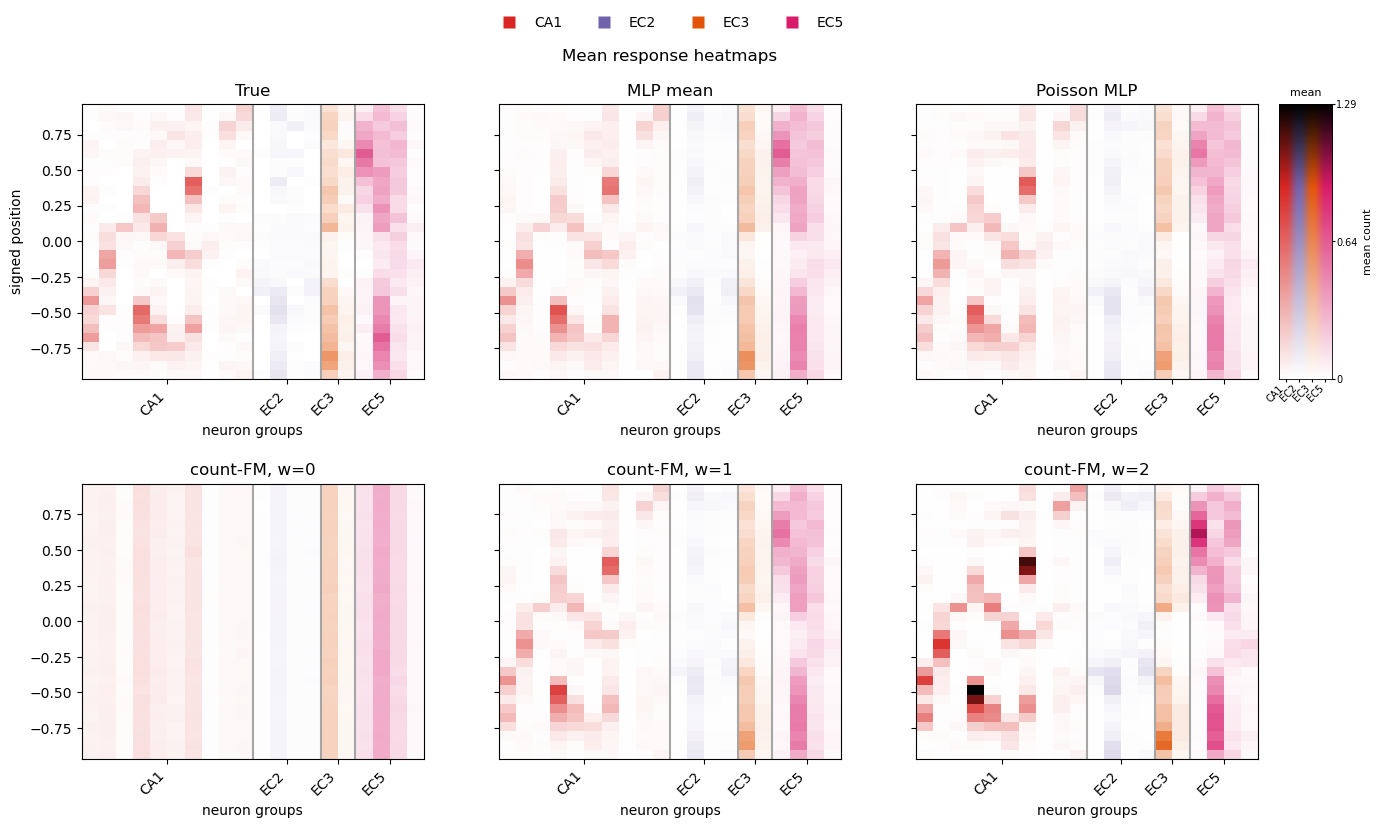

hc3_paper/figures/hc3_mean_response_all_models_region_colored_outer0_eval0.pdf
Shared raw vmax_heat_all: 1.289787234042553


In [61]:
# New Cell: all-model mean response heatmaps
# This expands row 1 of the combined figure to all models

from matplotlib.lines import Line2D

panel_order_heat_all = ["True"] + MODEL_ORDER

top_units_heat = np.asarray(top_units_rep, dtype=int)
group_info_heat = list(group_info_rep)

heat_stats_all = {}

for name in panel_order_heat_all:
    if name in show_stats_rep:
        heat_stats_all[name] = show_stats_rep[name]
    else:
        _, _, st = binned_stats(pred_mean_rep[name], split_rep["cov_test"], n_bins=N_BINS)
        heat_stats_all[name] = st["mean"]

vmax_heat_all = np.nanmax(
    np.stack([heat_stats_all[name][:, top_units_heat] for name in panel_order_heat_all], axis=0)
)
vmax_heat_all = vmax_heat_all if np.isfinite(vmax_heat_all) and vmax_heat_all > 0 else 1.0

region_to_cmap = {
    "CA1": "Reds",
    "CA3": "Blues",
    "DG": "Greens",
    "EC2": "Purples",
    "EC3": "Oranges",
    "EC4": "YlOrBr",
    "EC5": "PuRd",
}

unit_rgb = np.zeros((len(top_units_heat), 3), dtype=float)
region_legend_colors = {}

cursor = 0
for region, n_region in group_info_heat:
    idx = np.arange(cursor, cursor + n_region)
    cmap = plt.get_cmap(region_to_cmap.get(region, "Greys"))
    region_color = np.array(cmap(0.70)[:3])

    unit_rgb[idx] = region_color
    region_legend_colors[region] = region_color

    cursor += n_region

def region_colored_raw_heatmap(M, unit_rgb, vmax, mid=0.70):
    Z = np.nan_to_num(M / vmax, nan=0.0, posinf=1.0, neginf=0.0)
    Z = np.clip(Z, 0, 1)

    rgb = np.ones((Z.shape[0], Z.shape[1], 3), dtype=float)

    for j in range(Z.shape[1]):
        c = unit_rgb[j]
        z = Z[:, j]

        low = z <= mid
        high = ~low

        alpha = z[low] / mid
        rgb[low, j, :] = (1.0 - alpha[:, None]) * 1.0 + alpha[:, None] * c[None, :]

        beta = (z[high] - mid) / (1.0 - mid)
        rgb[high, j, :] = (1.0 - beta[:, None]) * c[None, :]

    return rgb

bounds = []
centers_x = []
cursor = 0

for region, n_region in group_info_heat:
    centers_x.append((cursor + 0.5 * n_region, region))
    cursor += n_region
    bounds.append(cursor)

bounds = bounds[:-1]

fig, axes = plt.subplots(2, 3, figsize=(14, 8.4), sharey=True)
axes = axes.ravel()

for ax, name in zip(axes, panel_order_heat_all):
    M = heat_stats_all[name][:, top_units_heat]
    rgb = region_colored_raw_heatmap(M, unit_rgb, vmax_heat_all)

    ax.imshow(
        rgb,
        aspect="auto",
        origin="lower",
        extent=[0, len(top_units_heat), centers_rep[0], centers_rep[-1]],
    )

    ax.set_title(name)
    ax.set_xlabel("neuron groups")

    for b in bounds:
        ax.axvline(b, color="0.65", linewidth=1.5)

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right")

axes[0].set_ylabel("signed position")
axes[0].set_ylabel("signed position")

handles = [
    Line2D(
        [0], [0],
        marker="s",
        linestyle="",
        markersize=8,
        markerfacecolor=region_legend_colors[r],
        markeredgecolor="none",
        label=r,
    )
    for r, _ in group_info_heat
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=min(len(handles), 7),
    frameon=False,
)

fig.suptitle("Mean response heatmaps", y=0.965)

# fig.subplots_adjust(
#     left=0.08,
#     right=0.99,
#     top=0.90,
#     bottom=0.12,
#     wspace=0.22,
#     hspace=0.38,
# )

fig.subplots_adjust(
    left=0.08,
    right=0.92,
    top=0.90,
    bottom=0.12,
    wspace=0.22,
    hspace=0.38,
)

fig.canvas.draw()

# thin multi-region mean-count key on the right
regions_key = [r for r, _ in group_info_heat]
n_grad = 256
z = np.linspace(0.0, 1.0, n_grad)

heat_key_rgb = np.ones((n_grad, len(regions_key), 3), dtype=float)
mid = 0.70

for j, region in enumerate(regions_key):
    c = region_legend_colors[region]

    low = z <= mid
    high = ~low

    alpha = z[low] / mid
    heat_key_rgb[low, j, :] = (1.0 - alpha[:, None]) * 1.0 + alpha[:, None] * c[None, :]

    beta = (z[high] - mid) / (1.0 - mid)
    heat_key_rgb[high, j, :] = (1.0 - beta[:, None]) * c[None, :]

ax_pos = [ax.get_position() for ax in axes]

x0_heat = max(p.x1 for p in ax_pos) + 0.015

# same height as one heatmap panel, aligned with the top row
p0 = axes[0].get_position()
y0_heat = p0.y0
y1_heat = p0.y1

cax_heat = fig.add_axes([x0_heat, y0_heat, 0.038, y1_heat - y0_heat])

cax_heat.imshow(
    heat_key_rgb,
    origin="lower",
    aspect="auto",
    extent=[0, len(regions_key), 0.0, vmax_heat_all],
)

cax_heat.set_xticks(np.arange(len(regions_key)) + 0.5)
cax_heat.set_xticklabels(regions_key, rotation=45, ha="right", fontsize=7)

cax_heat.set_yticks([0.0, 0.5 * vmax_heat_all, vmax_heat_all])
cax_heat.set_yticklabels([
    "0",
    f"{0.5 * vmax_heat_all:.2f}",
    f"{vmax_heat_all:.2f}",
])

cax_heat.yaxis.tick_right()
cax_heat.yaxis.set_label_position("right")
cax_heat.set_ylabel("mean count", fontsize=8)
cax_heat.set_title("mean", fontsize=8)
cax_heat.tick_params(axis="both", length=2, pad=1, labelsize=7)

for spine in cax_heat.spines.values():
    spine.set_linewidth(0.6)


heat_all_pdf = FIG_DIR / f"hc3_mean_response_all_models_region_colored_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
fig.savefig(heat_all_pdf, bbox_inches="tight")
plt.show()

print(heat_all_pdf)
print("Shared raw vmax_heat_all:", vmax_heat_all)

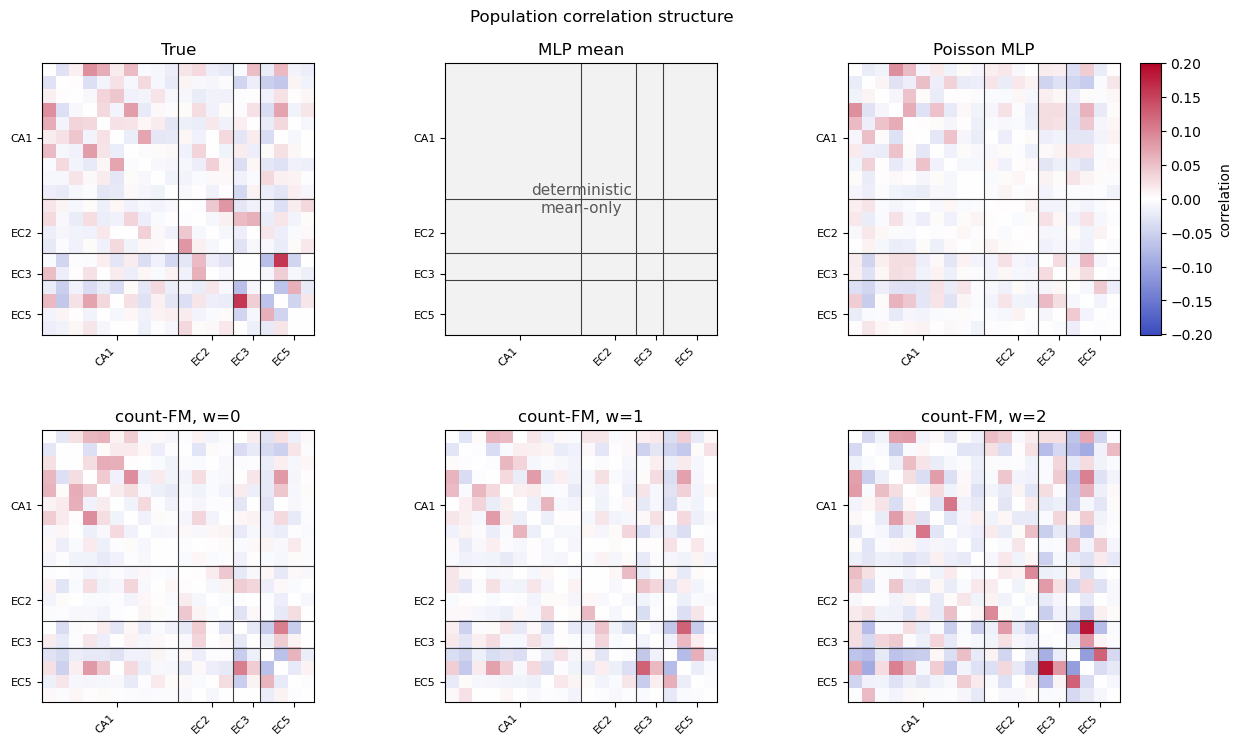

hc3_paper/figures/hc3_population_correlation_all_models_outer0_eval0.pdf
CORR_MODE: ordinary
SHOW_MLP_MEAN_CORR: False
Correlation color scale: (-0.20075960712203245, 0.20075960712203245)


In [62]:
# New Cell: all-model population correlation / residual correlation matrices

from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

CORR_MODE = "ordinary"        # "ordinary" or "residual"
SHOW_MLP_MEAN_CORR = False    # False: blank MLP mean panel, since it is deterministic

panel_order_corr_all = [
    "True",
    "MLP mean",
    "Poisson MLP",
    "count-FM, w=0",
    "count-FM, w=1",
    "count-FM, w=2",
]

top_units_corr = np.asarray(top_units_rep, dtype=int)
group_info_corr = list(group_info_rep)

def corr_from_X_plain(X, unit_ids=None, eps=1e-8):
    X = np.asarray(X, dtype=float)

    if unit_ids is not None:
        Z = X[:, unit_ids]
    else:
        Z = X

    Z = Z - Z.mean(axis=0, keepdims=True)

    sd = Z.std(axis=0, ddof=0)
    keep = sd > eps

    Zn = np.zeros_like(Z)
    Zn[:, keep] = Z[:, keep] / sd[keep][None, :]

    C = (Zn.T @ Zn) / max(Z.shape[0], 1)
    np.fill_diagonal(C, 0.0)

    return C

def flatten_draws_for_corr(draws, unit_ids):
    G = np.asarray(draws[:, :, unit_ids], dtype=float)
    return G.reshape(-1, len(unit_ids))

def blank_corr_matrix(n):
    return np.full((n, n), np.nan)

corr_panels_all = {}

if CORR_MODE == "ordinary":
    corr_panels_all["True"] = corr_from_X_plain(
        split_rep["X_test"],
        unit_ids=top_units_corr,
    )

    if SHOW_MLP_MEAN_CORR:
        corr_panels_all["MLP mean"] = corr_from_X_plain(
            pred_mean_rep["MLP mean"],
            unit_ids=top_units_corr,
        )
    else:
        corr_panels_all["MLP mean"] = blank_corr_matrix(len(top_units_corr))

    for name in ["Poisson MLP", "count-FM, w=0", "count-FM, w=1", "count-FM, w=2"]:
        Xg = flatten_draws_for_corr(pred_draws_rep[name], top_units_corr)
        corr_panels_all[name] = corr_from_X_plain(Xg, unit_ids=None)

    fig_title = "Population correlation structure"
    cbar_label = "correlation"
    save_tag = "population_correlation"

elif CORR_MODE == "residual":
    RESIDUAL_N_BINS = COV_N_BINS
    RESIDUAL_MIN_COUNT = COV_MIN_COUNT

    _, _, st_true_corr = binned_stats(
        split_rep["X_test"],
        split_rep["cov_test"],
        n_bins=RESIDUAL_N_BINS,
    )

    true_rows = stack_binned_residuals_mean(
        split_rep["X_test"],
        st_true_corr["mean"],
        split_rep["cov_test"],
        top_units_corr,
        n_bins=RESIDUAL_N_BINS,
        min_count=RESIDUAL_MIN_COUNT,
    )

    corr_panels_all["True"] = corr_from_rows_fixed(true_rows)

    if SHOW_MLP_MEAN_CORR:
        _, _, st_mlp = binned_stats(
            pred_mean_rep["MLP mean"],
            split_rep["cov_test"],
            n_bins=RESIDUAL_N_BINS,
        )

        mlp_rows = stack_binned_residuals_mean(
            pred_mean_rep["MLP mean"],
            st_mlp["mean"],
            split_rep["cov_test"],
            top_units_corr,
            n_bins=RESIDUAL_N_BINS,
            min_count=RESIDUAL_MIN_COUNT,
        )

        corr_panels_all["MLP mean"] = corr_from_rows_fixed(mlp_rows)
    else:
        corr_panels_all["MLP mean"] = blank_corr_matrix(len(top_units_corr))

    for name in ["Poisson MLP", "count-FM, w=0", "count-FM, w=1", "count-FM, w=2"]:
        _, _, st = binned_stats(
            pred_mean_rep[name],
            split_rep["cov_test"],
            n_bins=RESIDUAL_N_BINS,
        )

        rows = stack_binned_residuals_draws(
            pred_draws_rep[name],
            st["mean"],
            split_rep["cov_test"],
            top_units_corr,
            n_bins=RESIDUAL_N_BINS,
            min_count=RESIDUAL_MIN_COUNT,
        )

        corr_panels_all[name] = corr_from_rows_fixed(rows)

    fig_title = "Residual correlation structure"
    cbar_label = "residual correlation"
    save_tag = "residual_correlation"

else:
    raise ValueError("CORR_MODE must be 'ordinary' or 'residual'.")

for name in panel_order_corr_all:
    if corr_panels_all[name] is None:
        corr_panels_all[name] = blank_corr_matrix(len(top_units_corr))

bounds = []
centers_x = []
cursor = 0

for region, n_region in group_info_corr:
    centers_x.append((cursor + 0.5 * n_region, region))
    cursor += n_region
    bounds.append(cursor)

bounds = bounds[:-1]

corr_vals = []
for name in panel_order_corr_all:
    C = corr_panels_all[name]
    offdiag = ~np.eye(C.shape[0], dtype=bool)
    vals = C[offdiag]
    vals = vals[np.isfinite(vals)]
    if len(vals) > 0:
        corr_vals.append(vals)

corr_vals = np.concatenate(corr_vals)

corr_data_min = float(np.nanmin(corr_vals))
corr_data_max = float(np.nanmax(corr_vals))

corr_pad = 0.05 * (corr_data_max - corr_data_min)
if not np.isfinite(corr_pad) or corr_pad <= 0:
    corr_pad = 0.05

# corr_vmin = min(corr_data_min - corr_pad, -1e-6)
# corr_vmax = max(corr_data_max + corr_pad,  1e-6)

corr_absmax = max(
    abs(corr_data_min - corr_pad),
    abs(corr_data_max + corr_pad),
    1e-6,
)

corr_vmin = -corr_absmax
corr_vmax = corr_absmax

corr_norm = TwoSlopeNorm(
    vmin=corr_vmin,
    vcenter=0.0,
    vmax=corr_vmax,
)

corr_cmap = LinearSegmentedColormap.from_list(
    "blue_white_red",
    [
        (0.0, "#3b4cc0"),
        (0.5, "#ffffff"),
        (1.0, "#b40426"),
    ],
)
corr_cmap.set_bad("#f2f2f2")

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.2))
axes = axes.ravel()

for ax, name in zip(axes, panel_order_corr_all):
    C = corr_panels_all[name]

    ax.imshow(
        C,
        cmap=corr_cmap,
        norm=corr_norm,
        origin="upper",
        aspect="equal",
    )

    ax.set_title(name)

    if name == "MLP mean" and not SHOW_MLP_MEAN_CORR:
        ax.text(
            0.5,
            0.5,
            "deterministic\nmean-only",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=11,
            color="0.35",
        )

    ax.set_xticks([c for c, _ in centers_x])
    ax.set_xticklabels([lab for _, lab in centers_x], rotation=45, ha="right", fontsize=8)

    ax.set_yticks([c for c, _ in centers_x])
    ax.set_yticklabels([lab for _, lab in centers_x], fontsize=8)

    for b in bounds:
        ax.axvline(b - 0.5, color="0.25", linewidth=0.8)
        ax.axhline(b - 0.5, color="0.25", linewidth=0.8)

fig.subplots_adjust(
    left=0.07,
    right=0.90,
    top=0.90,
    bottom=0.12,
    wspace=0.28,
    hspace=0.35,
)

fig.canvas.draw()
# ax_pos = [ax.get_position() for ax in axes]

# x0 = max(p.x1 for p in ax_pos) + 0.015
# y0 = min(p.y0 for p in ax_pos)
# y1 = max(p.y1 for p in ax_pos)

# sm = ScalarMappable(norm=corr_norm, cmap=corr_cmap)
# sm.set_array([])

# cax = fig.add_axes([x0, y0, 0.015, y1 - y0])

ax_pos = [ax.get_position() for ax in axes]

x0 = max(p.x1 for p in ax_pos) + 0.015

# same height as one correlation panel, aligned with the top row
p0 = axes[0].get_position()
y0 = p0.y0
y1 = p0.y1

sm = ScalarMappable(norm=corr_norm, cmap=corr_cmap)
sm.set_array([])

cax = fig.add_axes([x0, y0, 0.015, y1 - y0])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(cbar_label)

fig.suptitle(fig_title, y=0.965)

corr_all_pdf = FIG_DIR / f"hc3_{save_tag}_all_models_outer{REP_OUTER_SEED}_eval{REP_EVAL_SEED}.pdf"
fig.savefig(corr_all_pdf, bbox_inches="tight")

plt.show()

print(corr_all_pdf)
print("CORR_MODE:", CORR_MODE)
print("SHOW_MLP_MEAN_CORR:", SHOW_MLP_MEAN_CORR)
print("Correlation color scale:", (corr_vmin, corr_vmax))